# 🧬 Parkinson’s Disease Detection using Keystroke Dynamics

This project uses machine learning to detect early-stage Parkinson’s Disease based on typing behaviour (keystroke dynamics).

We apply feature selection, class balancing, and multiple models to achieve high classification accuracy.

## 📦 Import Libraries

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from scipy.stats import pearsonr
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC


## 📊 Load and Merge Dataset

In [6]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

tappy_data_path = DATA_DIR / "Tappy Data"
user_data_path = DATA_DIR / "Archived users"

In [7]:
directory_path = tappy_data_path

df_all_tappy_data = pd.DataFrame()

for filename in os.listdir(directory_path):
    if filename.endswith('.txt'):
        file_path = os.path.join(directory_path, filename)
        df = pd.read_csv(file_path, delimiter=r'\s+', header=None,
                         names=['UserKey', 'Date', 'Timestamp', 'Hand', 'Holdtime', 'Direction', 'Latencytime', 'Flighttime'], low_memory=False)
        for col in ['Holdtime', 'Latencytime', 'Flighttime']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df_all_tappy_data = pd.concat([df_all_tappy_data, df], ignore_index=True)

df_all_tappy_data

,UserKey,Date,Timestamp,Hand,Holdtime,Direction,Latencytime,Flighttime
0,NMMGWRY6SO,170301,08:45:42.125,L,187.5,LL,421.9,281.3
1,NMMGWRY6SO,170301,08:45:42.422,L,203.1,LL,281.3,93.8
2,NMMGWRY6SO,170301,08:48:29.031,L,203.1,LL,296.9,125.0
3,NMMGWRY6SO,170301,08:48:29.266,L,218.8,LL,218.8,15.6
4,NMMGWRY6SO,170301,08:48:29.484,R,187.5,LR,250.0,31.3
...,...,...,...,...,...,...,...,...
9316853,3HYXJCTCNT,170126,14:12:47.000,S,58.6,RS,214.8,160.2
9316854,3HYXJCTCNT,170126,14:12:49.422,R,85.9,LR,175.8,82.0
9316855,3HYXJCTCNT,170126,14:12:49.598,R,39.1,RR,222.7,136.7
9316856,3HYXJCTCNT,170126,14:12:51.160,L,43.0,LL,125.0,285.2


In [8]:
directory_path = user_data_path

df_all_user_data = pd.DataFrame()

for filename in os.listdir(directory_path):
    if filename.endswith('.txt') and filename.startswith('User_'):
        file_path = os.path.join(directory_path, filename)
        user_key = filename.replace('User_', '').replace('.txt', '')
        data = {}
        with open(file_path, 'r') as file:
            for line in file:
                key, value = line.strip().split(':')
                data[key.strip()] = value.strip()
        df = pd.DataFrame([data])
        df['UserKey'] = user_key
        df_all_user_data = pd.concat([df_all_user_data, df], ignore_index=True)

df_all_user_data


,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other,UserKey
0,,Male,True,True,,Left,Don't know,Mild,True,False,False,False,PJU53Y7KVB
1,1952,Male,False,False,------,None,Don't know,------,False,False,False,False,G6OE5CXQPY
2,1951,Male,True,True,2003,Left,Don't know,Severe,True,False,False,False,2X17VCRRQA
3,1947,Female,True,True,2014,None,Don't know,Medium,True,False,False,True,I3U47MF5UF
4,1965,Male,True,True,2007,Right,Don't know,Severe,True,False,True,False,L7Q16SJ7KP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,1946,Female,True,True,2012,Left,Don't know,Medium,True,False,False,True,VIAXR21TSC
223,1943,Female,True,True,2013,None,Don't know,Mild,True,False,False,False,IDZHIUK2W2
224,1953,Male,True,True,2016,None,Don't know,Severe,True,False,False,True,SW61HF6XRY
225,1958,Male,True,True,2013,Right,Don't know,Medium,True,False,False,False,2JTCBKUP8T


## 🧹 Data Preprocessing
- Handling missing values  
- Removing duplicates  
- Outlier removal (IQR)  
- Feature scaling  

In [10]:
missing_keys = df_all_tappy_data[~df_all_tappy_data['UserKey'].isin(df_all_user_data['UserKey'])]['UserKey'].unique()
print(f"Number of unique UserKeys in tappy data without a match in user data: {len(missing_keys)}")


Number of unique UserKeys in tappy data without a match in user data: 116


In [11]:
df_missing_userkeys = df_all_tappy_data[df_all_tappy_data['UserKey'].isin(missing_keys)]

print(df_missing_userkeys.describe(include='all'))

           UserKey    Date     Timestamp    Hand      Holdtime Direction  \
count       302059  302060        302060  302060  3.019870e+05    302060   
unique         115     292        297547      58           NaN        49   
top     QEYMRM1ZSM  160813  10:23:18.125       L           NaN        LL   
freq        221752    8810             3  143666           NaN     64954   
mean           NaN     NaN           NaN     NaN  1.538577e+02       NaN   
std            NaN     NaN           NaN     NaN  1.811258e+04       NaN   
min            NaN     NaN           NaN     NaN  0.000000e+00       NaN   
25%            NaN     NaN           NaN     NaN  8.980000e+01       NaN   
50%            NaN     NaN           NaN     NaN  1.172000e+02       NaN   
75%            NaN     NaN           NaN     NaN  1.484000e+02       NaN   
max            NaN     NaN           NaN     NaN  9.947047e+06       NaN   

          Latencytime     Flighttime  
count   301966.000000  301985.000000  
unique   

In [12]:
df_merged_tappy_and_user = pd.merge(df_all_tappy_data, df_all_user_data, on='UserKey', how='inner')

print(df_merged_tappy_and_user.head())
print(f"The dataset after inner join has {df_merged_tappy_and_user.shape[0]} rows.")


      UserKey    Date     Timestamp Hand  Holdtime Direction  Latencytime  \
0  NMMGWRY6SO  170301  08:45:42.125    L     187.5        LL        421.9   
1  NMMGWRY6SO  170301  08:45:42.422    L     203.1        LL        281.3   
2  NMMGWRY6SO  170301  08:48:29.031    L     203.1        LL        296.9   
3  NMMGWRY6SO  170301  08:48:29.266    L     218.8        LL        218.8   
4  NMMGWRY6SO  170301  08:48:29.484    R     187.5        LR        250.0   

   Flighttime BirthYear Gender Parkinsons Tremors DiagnosisYear  Sided  \
0       281.3      1948   Male       True   False          2016  Right   
1        93.8      1948   Male       True   False          2016  Right   
2       125.0      1948   Male       True   False          2016  Right   
3        15.6      1948   Male       True   False          2016  Right   
4        31.3      1948   Male       True   False          2016  Right   

        UPDRS Impact Levadopa     DA   MAOB  Other  
0  Don't know   Mild    False  False  F

In [13]:
print(df_merged_tappy_and_user['UserKey'].nunique())

217


In [14]:
df = df_merged_tappy_and_user

# Filtering rows to check
df_parkinsons_dash = df[(df['Levadopa'] == 'False') & (df['Impact'] == 'Mild')]

print(f"Number of records: {len(df_parkinsons_dash)}")


Number of records: 1250263


Descriptive Statistics for Holdtime, Latencytime, and Flighttime:
           Holdtime   Latencytime    Flighttime
count  9.014491e+06  9.014380e+06  9.014499e+06
mean   7.810403e+01  2.605852e+02  1.881616e+02
std    6.458440e+04  3.473011e+02  5.699308e+02
min   -8.639992e+07  1.000000e+00  0.000000e+00
25%    7.810000e+01  1.641000e+02  9.380000e+01
50%    1.016000e+02  2.305000e+02  1.602000e+02
75%    1.367000e+02  3.242000e+02  2.500000e+02
max    1.359442e+07  1.702050e+05  1.703010e+05

Skewness of Holdtime, Latencytime, and Flighttime:
Holdtime      -1326.872246
Latencytime     392.107012
Flighttime      271.353213
dtype: float64

Kurtosis of Holdtime, Latencytime, and Flighttime:
Holdtime       1.776745e+06
Latencytime    1.826765e+05
Flighttime     7.757811e+04
dtype: float64


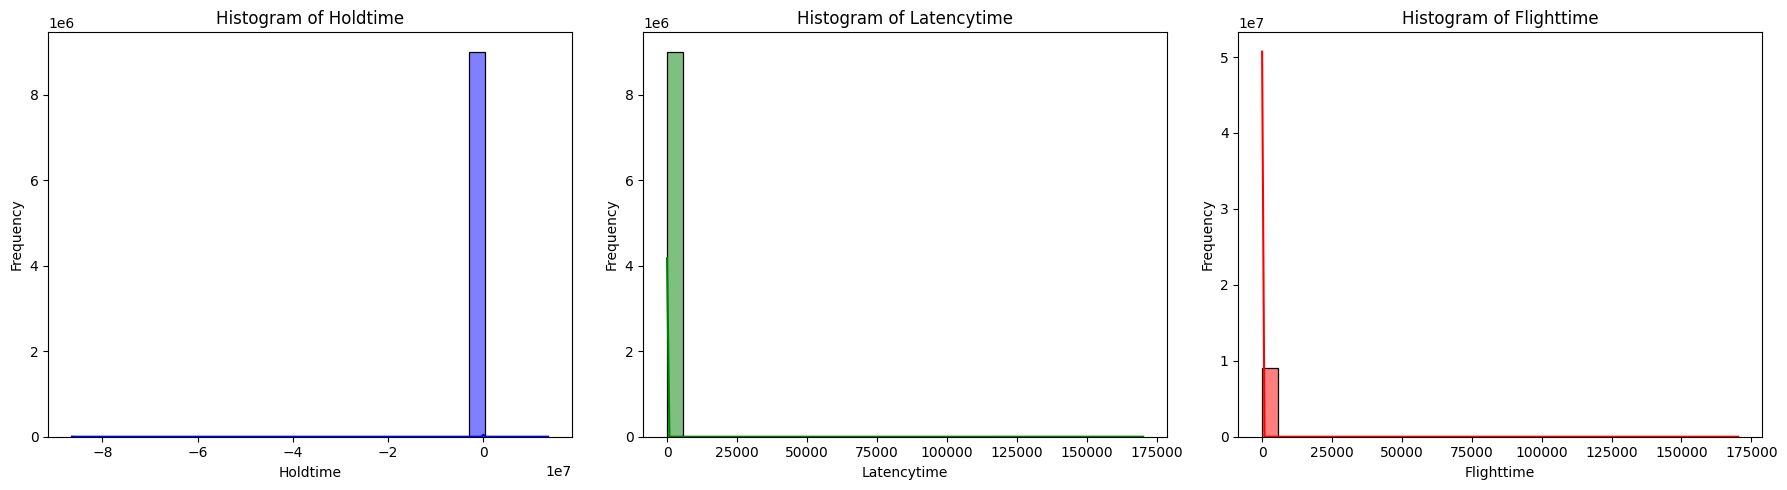

In [15]:
# Descriptive Statistics for Numerical Features
descriptive_stats = df[['Holdtime', 'Latencytime', 'Flighttime']].describe()
print("Descriptive Statistics for Holdtime, Latencytime, and Flighttime:")
print(descriptive_stats)

# Additional Statistics
# Skewness
skewness = df[['Holdtime', 'Latencytime', 'Flighttime']].skew()
print("\nSkewness of Holdtime, Latencytime, and Flighttime:")
print(skewness)

# Kurtosis
kurtosis = df[['Holdtime', 'Latencytime', 'Flighttime']].kurtosis()
print("\nKurtosis of Holdtime, Latencytime, and Flighttime:")
print(kurtosis)

# Histograms for Hold Time, Latency Time, and Flight Time
plt.figure(figsize=(18, 5))

# Plotting histogram for Holdtime
plt.subplot(1, 3, 1)
sns.histplot(df['Holdtime'], kde=True, bins=30, color='blue')
plt.title('Histogram of Holdtime')
plt.xlabel('Holdtime')
plt.ylabel('Frequency')

# Plotting histogram for Latencytime
plt.subplot(1, 3, 2)
sns.histplot(df['Latencytime'], kde=True, bins=30, color='green')
plt.title('Histogram of Latencytime')
plt.xlabel('Latencytime')
plt.ylabel('Frequency')

# Plotting histogram for Flighttime
plt.subplot(1, 3, 3)
sns.histplot(df['Flighttime'], kde=True, bins=30, color='red')
plt.title('Histogram of Flighttime')
plt.xlabel('Flighttime')
plt.ylabel('Frequency')

# Display the plots
plt.tight_layout()
plt.show()

In [16]:
df = df_merged_tappy_and_user

# Combining '------' and '' into 'Mild' in the 'Impact' column
df['Impact'] = df['Impact'].replace(['------', ''], 'Mild')

# Filtering out users with fewer than 2000 keystrokes
user_counts = df['UserKey'].value_counts()
filtered_users = user_counts[user_counts >= 2000].index
df_filtered = df[df['UserKey'].isin(filtered_users)]
print(f"Number of users after filtering for keystrokes: {df_filtered['UserKey'].nunique()}")

# Filtering for 'Mild' and 'Medium' severity in the 'Impact' column
#df_filtered_mild = df_filtered[df_filtered['Impact'] == 'Mild']
df_filtered_mild = df_filtered[df_filtered['Impact'].isin(['Mild', 'Medium'])]
print(f"Number of users after filtering for 'Mild' severity: {df_filtered_mild['UserKey'].nunique()}")

# Filtering out those taking Levodopa
df_filtered_combined = df_filtered_mild[df_filtered_mild['Levadopa'] == 'False']
print(f"Number of users after filtering out Levodopa: {df_filtered_combined['UserKey'].nunique()}")


Number of users after filtering for keystrokes: 131
Number of users after filtering for 'Mild' severity: 118
Number of users after filtering out Levodopa: 64


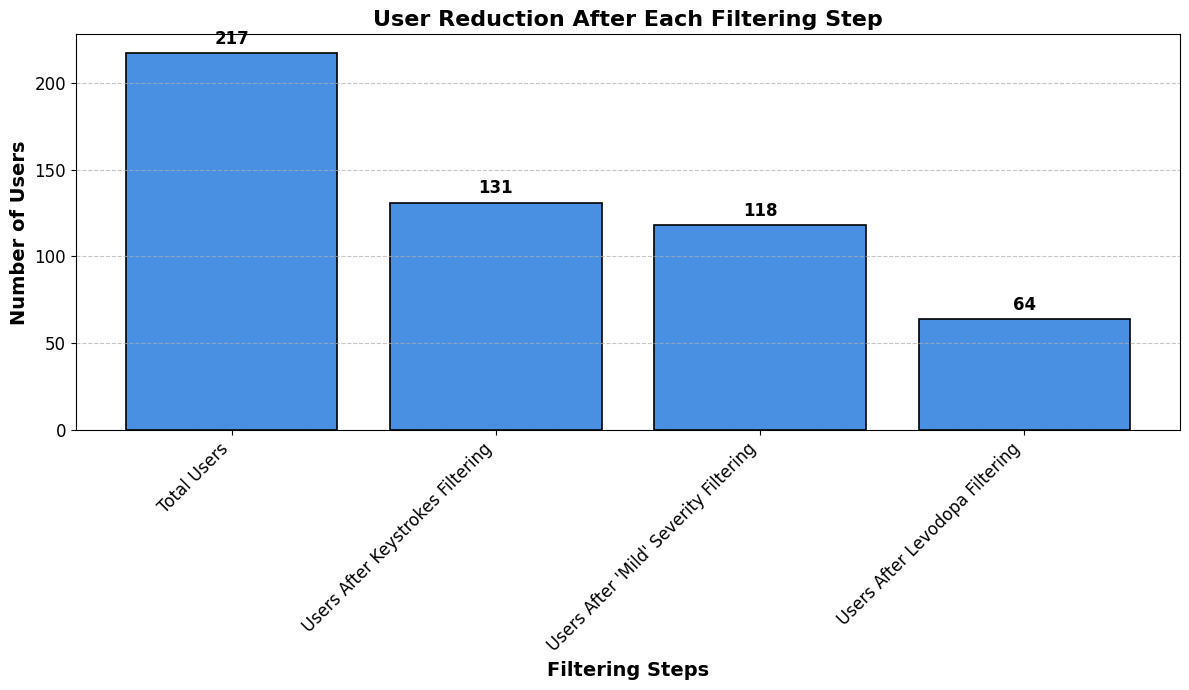

In [17]:
steps = [
    "Total Users",
    "Users After Keystrokes Filtering",
    "Users After 'Mild' Severity Filtering",
    "Users After Levodopa Filtering"
]

user_counts = [217, 131, 118, 64]

# Plotting the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(steps, user_counts, color='#4A90E2', edgecolor='black', linewidth=1.2)

# Adding the value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Enhancing the visual appeal
plt.xlabel('Filtering Steps', fontsize=14, fontweight='bold')
plt.ylabel('Number of Users', fontsize=14, fontweight='bold')
plt.title('User Reduction After Each Filtering Step', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, ha="right")
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig("../results/user_reduction_bar_chart.png")
plt.show()


In [18]:
# Group split based on UserKey
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_filtered_combined, groups=df_filtered_combined['UserKey']))

train_data = df_filtered_combined.iloc[train_idx]
test_data = df_filtered_combined.iloc[test_idx]

# Verifying the split to ensure no overlap in UserKey
train_user_keys = set(train_data['UserKey'])
test_user_keys = set(test_data['UserKey'])
overlap = train_user_keys.intersection(test_user_keys)

print(f"Number of unique UserKeys in training set: {len(train_user_keys)}")
print(f"Number of unique UserKeys in test set: {len(test_user_keys)}")
print(f"Number of overlapping UserKeys between training and test sets: {len(overlap)}")

Number of unique UserKeys in training set: 44
Number of unique UserKeys in test set: 20
Number of overlapping UserKeys between training and test sets: 0


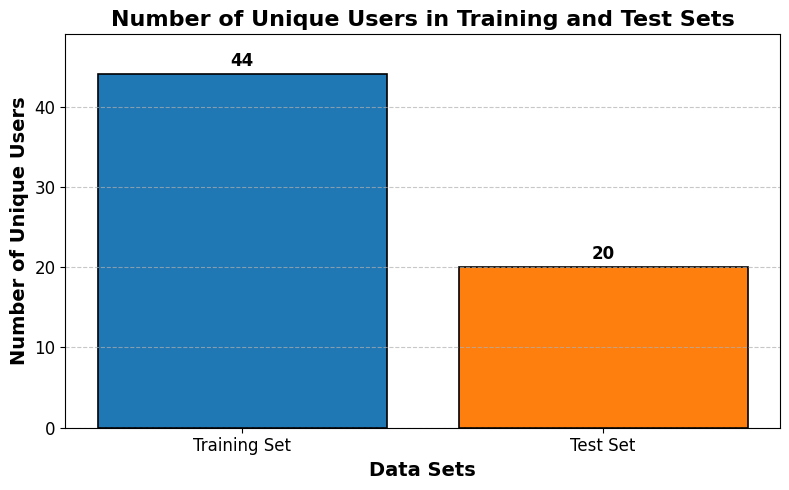

In [19]:
sets = ['Training Set', 'Test Set']
user_counts = [44, 20]  # These values are based on the code output

# Plotting the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sets, user_counts, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.2)

# Adding the value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Enhancing the visual appeal
plt.xlabel('Data Sets', fontsize=14, fontweight='bold')
plt.ylabel('Number of Unique Users', fontsize=14, fontweight='bold')
plt.title('Number of Unique Users in Training and Test Sets', fontsize=16, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, max(user_counts) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig("../results/unique_users_training_vs_test_sets.png")
plt.show()


In [20]:
import pandas as pd

# Checking for overlapping rows between training and test sets
overlap = pd.merge(train_data, test_data, how='inner')
if not overlap.empty:
    print("Warning: Data leakage detected!")
else:
    print("No data leakage detected.")


No data leakage detected.


In [21]:
print(train_data.nunique())

UserKey               44
Date                 409
Timestamp        2751483
Hand                  53
Holdtime            1487
Direction             59
Latencytime         2895
Flighttime          2672
BirthYear             22
Gender                 2
Parkinsons             2
Tremors                2
DiagnosisYear          9
Sided                  3
UPDRS                  1
Impact                 2
Levadopa               1
DA                     2
MAOB                   2
Other                  2
dtype: int64


In [22]:
print(test_data.nunique())

UserKey               20
Date                 378
Timestamp        2221092
Hand                  37
Holdtime            1222
Direction             30
Latencytime         2787
Flighttime          2681
BirthYear             16
Gender                 2
Parkinsons             2
Tremors                2
DiagnosisYear          7
Sided                  3
UPDRS                  1
Impact                 2
Levadopa               1
DA                     2
MAOB                   2
Other                  2
dtype: int64


In [23]:
# Checking and Removing duplicates in training data
train_duplicates = train_data.duplicated()
num_train_duplicates = train_duplicates.sum()
print(f"Number of duplicate rows in training data: {num_train_duplicates}")

# Removing duplicates in training data
train_data = train_data.drop_duplicates()

# Verifying duplicates have been removed in training data
train_duplicates_after_removal = train_data.duplicated().sum()
print(f"Number of duplicate rows in training data after removal: {train_duplicates_after_removal}")

# Checking and Removing Duplicates in test data
test_duplicates = test_data.duplicated()
num_test_duplicates = test_duplicates.sum()
print(f"Number of duplicate rows in test data: {num_test_duplicates}")

# Removing duplicates in test data
test_data = test_data.drop_duplicates()

# Verifying duplicates have been removed in test data
test_duplicates_after_removal = test_data.duplicated().sum()
print(f"Number of duplicate rows in test data after removal: {test_duplicates_after_removal}")



Number of duplicate rows in training data: 13927
Number of duplicate rows in training data after removal: 0
Number of duplicate rows in test data: 14982
Number of duplicate rows in test data after removal: 0


In [24]:
# Checking for missing values in all columns in the training set
missing_train_all = train_data.isnull().sum()
print('Missing values in the training set:')
print(missing_train_all)

# Checking for missing values in all columns in the test set
missing_test_all = test_data.isnull().sum()
print('Missing values in the test set:')
print(missing_test_all)


Missing values in the training set:
UserKey            0
Date               0
Timestamp          0
Hand               0
Holdtime          78
Direction          0
Latencytime      112
Flighttime        82
BirthYear          0
Gender             0
Parkinsons         0
Tremors            0
DiagnosisYear      0
Sided              0
UPDRS              0
Impact             0
Levadopa           0
DA                 0
MAOB               0
Other              0
dtype: int64
Missing values in the test set:
UserKey           0
Date              0
Timestamp         0
Hand              0
Holdtime         38
Direction         0
Latencytime      52
Flighttime       45
BirthYear         0
Gender            0
Parkinsons        0
Tremors           0
DiagnosisYear     0
Sided             0
UPDRS             0
Impact            0
Levadopa          0
DA                0
MAOB              0
Other             0
dtype: int64


In [25]:
# Defining columns to impute
columns_to_impute = ['Holdtime', 'Latencytime', 'Flighttime']

median_values = {}
for col in columns_to_impute:
    median_train = train_data[col].median()
    median_values[col] = median_train
    train_data[col].fillna(median_train, inplace=True)
    test_data[col].fillna(median_train, inplace=True)  # Using the same median as the training set for consistency


# Output the median values used for imputation
print("\nMedian values used for imputation:")
for col, median in median_values.items():
    print(f"{col}: {median}")

# Verifying missing values are imputed in training and test set

missing_train_after_imputation = train_data.isnull().sum()
print("\nMissing values in training data after imputation:")
print(missing_train_after_imputation[missing_train_after_imputation > 0])

missing_test_after_imputation = test_data.isnull().sum()
print("\nMissing values in test data after imputation:")
print(missing_test_after_imputation[missing_test_after_imputation > 0])


Median values used for imputation:
Holdtime: 101.6
Latencytime: 210.9
Flighttime: 136.7


/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/2565514314.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[col].fillna(median_train, inplace=True)
/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/2565514314.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al


Missing values in training data after imputation:
Series([], dtype: int64)

Missing values in test data after imputation:
Series([], dtype: int64)


In [26]:
print(train_data.count())
print(test_data.count())

UserKey          3053710
Date             3053710
Timestamp        3053710
Hand             3053710
Holdtime         3053710
Direction        3053710
Latencytime      3053710
Flighttime       3053710
BirthYear        3053710
Gender           3053710
Parkinsons       3053710
Tremors          3053710
DiagnosisYear    3053710
Sided            3053710
UPDRS            3053710
Impact           3053710
Levadopa         3053710
DA               3053710
MAOB             3053710
Other            3053710
dtype: int64
UserKey          2380862
Date             2380862
Timestamp        2380862
Hand             2380862
Holdtime         2380862
Direction        2380862
Latencytime      2380862
Flighttime       2380862
BirthYear        2380862
Gender           2380862
Parkinsons       2380862
Tremors          2380862
DiagnosisYear    2380862
Sided            2380862
UPDRS            2380862
Impact           2380862
Levadopa         2380862
DA               2380862
MAOB             2380862
Other       

In [27]:
# Removing outliers
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

columns_to_check = ['Holdtime', 'Latencytime', 'Flighttime']

# Removing outliers in training data
print(f"\nShape of training data before removing outliers: {train_data.shape}")
train_data = remove_outliers(train_data, columns_to_check)
print(f"Shape of training data after removing outliers: {train_data.shape}")

# Removing outliers in test data
print(f"\nShape of test data before removing outliers: {test_data.shape}")
test_data = remove_outliers(test_data, columns_to_check)
print(f"Shape of test data after removing outliers: {test_data.shape}")

print("\nData after removing outliers:")
print("Training data:")
print(train_data.describe())
print("\nTest data:")
print(test_data.describe())



Shape of training data before removing outliers: (3053710, 20)
Shape of training data after removing outliers: (2780083, 20)

Shape of test data before removing outliers: (2380862, 20)
Shape of test data after removing outliers: (2207906, 20)

Data after removing outliers:
Training data:
           Holdtime   Latencytime    Flighttime
count  2.780083e+06  2.780083e+06  2.780083e+06
mean   1.036649e+02  2.207920e+02  1.443892e+02
std    4.146647e+01  9.519273e+01  8.830737e+01
min    0.000000e+00  1.000000e+00  1.000000e+00
25%    7.810000e+01  1.504000e+02  7.810000e+01
50%    1.016000e+02  2.031000e+02  1.289000e+02
75%    1.289000e+02  2.773000e+02  1.992000e+02
max    2.148000e+02  4.941000e+02  3.906000e+02

Test data:
           Holdtime   Latencytime    Flighttime
count  2.207906e+06  2.207906e+06  2.207906e+06
mean   9.082725e+01  2.364878e+02  1.604791e+02
std    3.218411e+01  9.177132e+01  9.030827e+01
min    5.900000e+00  1.000000e+00  1.000000e+00
25%    7.030000e+01  1.699

In [28]:
from sklearn.preprocessing import MinMaxScaler

# Applying Min-Max Scaling
scaler = MinMaxScaler()

# Fitting the scaler on the training data
train_data[columns_to_check] = scaler.fit_transform(train_data[columns_to_check])

# Applying the scaler to the test data
test_data[columns_to_check] = scaler.transform(test_data[columns_to_check])

print("\nTraining data after scaling:")
print(train_data.describe())
print("\nTest data after scaling:")
print(test_data.describe())



Training data after scaling:
           Holdtime   Latencytime    Flighttime
count  2.780083e+06  2.780083e+06  2.780083e+06
mean   4.826112e-01  4.457351e-01  3.680421e-01
std    1.930469e-01  1.930495e-01  2.266616e-01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    3.635940e-01  3.029811e-01  1.978953e-01
50%    4.729981e-01  4.098560e-01  3.282854e-01
75%    6.000931e-01  5.603326e-01  5.087269e-01
max    1.000000e+00  1.000000e+00  1.000000e+00

Test data after scaling:
           Holdtime   Latencytime    Flighttime
count  2.207906e+06  2.207906e+06  2.207906e+06
mean   4.228457e-01  4.775661e-01  4.093406e-01
std    1.498329e-01  1.861110e-01  2.317974e-01
min    2.746741e-02  0.000000e+00  0.000000e+00
25%    3.272812e-01  3.425269e-01  2.381930e-01
50%    3.999069e-01  4.575137e-01  3.934805e-01
75%    5.093110e-01  5.842628e-01  5.590349e-01
max    8.272812e-01  9.896573e-01  1.040298e+00


In [29]:
# Categorical columns to inspect
categorical_columns = ['Hand', 'Direction', 'Gender', 'UPDRS', 'Impact', 'Levadopa', 'DA', 'MAOB', 'Other', 'Parkinsons']

# Inspecting unique values in each categorical column in training set
for column in categorical_columns:
    unique_values = train_data[column].unique()
    print(f'Unique values in {column}: {unique_values}')


Unique values in Hand: ['L' 'R' 'S' '160824' '160923' '21:40:16.578' '12:53:06.406'
 '16:40:29.469' '161116' '08:28:20.328' '161129' '170120' '160825'
 '16:17:54.109' '160705' '161223' '170224' '170111' '170113' '170116'
 '170126' '14:19:25.051' '161023' '161026' '170221' '11:15:20.910'
 '00:06:09.599' '09:57:12.035' '08:44:17.834' '161217' '161224' '160905'
 '161108' '161109' '161111' '161113' '161114' '00:20:43.320' '161115'
 '23:36:04.188' '161127' '161128' '170115' '170201' '170207' '161019'
 '161012' '11:26:13.227']
Unique values in Direction: ['LL' 'LR' 'RL' 'RR' 'RS' 'LS' 'SR' 'SL' 'SS' 'R' 'L' '0156.3' '0109.4'
 '0125.0' '170212' '161007' 'FHEOPKL3QQ' '161028' '0218.8' '170123'
 '161118' 'S' '0121.1' '161125' '170116' '160821' '0085.9' 'OMCPRWYBSQ'
 '161023' 'LQCFNDCZPQH' 'QCFNDCZPQH' '0112.0' '160823' '161205' '0003.9'
 '0127.0' '161216' '160811' '160825' '161101' '0038.0' 'RLZY9CCHSPF2'
 '161116' '161119' '0140.6' '161122' 'ZY9CCHSPF2' '161130' '161011'
 'WBS5I7VF1G' '161008'

In [30]:
# Categorical columns to inspect
categorical_columns = ['Hand', 'Direction', 'Gender', 'UPDRS', 'Impact', 'Levadopa', 'DA', 'MAOB', 'Other', 'Parkinsons']

# Inspecting unique values in each categorical column in test set
for column in categorical_columns:
    unique_values = test_data[column].unique()
    print(f'Unique values in {column}: {unique_values}')


Unique values in Hand: ['S' 'L' 'R' '170301' '160912' '15:53:19.305' '08:40:34.025' '160906'
 '160908' '160607' '160609' '170201' '170212' '170215' '170218' '170220'
 '170221' '170222' '170223' '170226' '170302' '161010' '160726'
 '12:01:03.844' '170107' '170115' '15:38:02.125' '11:25:55.363' '170103'
 '21:56:37.070' '170217' '170225' '161116']
Unique values in Direction: ['RS' 'RL' 'LR' 'RR' 'LS' 'SL' 'LL' 'SR' 'SS' '160815' 'R' 'L' '0113.3'
 '0171.9' 'VVYPNRQ5KG' '170203' '95S93AXF86' 'S' '170224' '81NEUZEBXI'
 '0125.0' '0031.3' '0105.5' 'V2SZVYXBOD']
Unique values in Gender: ['Female' 'Male']
Unique values in UPDRS: ["Don't know"]
Unique values in Impact: ['Medium' 'Mild']
Unique values in Levadopa: ['False']
Unique values in DA: ['True' 'False']
Unique values in MAOB: ['False' 'True']
Unique values in Other: ['False' 'True']
Unique values in Parkinsons: ['True' 'False']


In [31]:
# Defining valid entries for categorical columns
valid_entries = {
    'Hand': ['S', 'L', 'R'],
    'Direction': ['LL', 'LR', 'RL', 'RR', 'LS', 'RS', 'SS', 'SR', 'SL'],
}

# Filtering categorical columns in training data
for column, valid_values in valid_entries.items():
    train_data = train_data[train_data[column].isin(valid_values)]

# Filtering categorical columns in test data
for column, valid_values in valid_entries.items():
    test_data = test_data[test_data[column].isin(valid_values)]

print("\nTraining data after filtering categorical columns:")
print(train_data.describe(include='all'))
print("\nTest data after filtering categorical columns:")
print(test_data.describe(include='all'))


Training data after filtering categorical columns:
           UserKey       Date     Timestamp     Hand      Holdtime Direction  \
count      2780000  2780000.0       2780000  2780000  2.780000e+06   2780000   
unique          44      397.0       2527042        3           NaN         9   
top     G6OE5CXQPY   170120.0  18:55:22.672        L           NaN        LL   
freq        622847    61689.0             6  1301337           NaN    573657   
mean           NaN        NaN           NaN      NaN  4.826115e-01       NaN   
std            NaN        NaN           NaN      NaN  1.930494e-01       NaN   
min            NaN        NaN           NaN      NaN  0.000000e+00       NaN   
25%            NaN        NaN           NaN      NaN  3.635940e-01       NaN   
50%            NaN        NaN           NaN      NaN  4.729981e-01       NaN   
75%            NaN        NaN           NaN      NaN  6.000931e-01       NaN   
max            NaN        NaN           NaN      NaN  1.000000e+00  

In [32]:
print(f'Training set shape after cleaning: {train_data.shape}')
print(f'Test set shape after cleaning: {test_data.shape}')

Training set shape after cleaning: (2780000, 20)
Test set shape after cleaning: (2207865, 20)


In [33]:
print(train_data.head())

      UserKey    Date     Timestamp Hand  Holdtime Direction  Latencytime  \
0  NMMGWRY6SO  170301  08:45:42.125    L  0.872905        LL     0.853579   
1  NMMGWRY6SO  170301  08:45:42.422    L  0.945531        LL     0.568445   
2  NMMGWRY6SO  170301  08:48:29.031    L  0.945531        LL     0.600081   
4  NMMGWRY6SO  170301  08:48:29.484    R  0.872905        LR     0.504969   
5  NMMGWRY6SO  170301  08:49:14.234    L  0.945531        RL     0.409856   

   Flighttime BirthYear Gender Parkinsons Tremors DiagnosisYear  Sided  \
0    0.719456      1948   Male       True   False          2016  Right   
1    0.238193      1948   Male       True   False          2016  Right   
2    0.318275      1948   Male       True   False          2016  Right   
4    0.077772      1948   Male       True   False          2016  Right   
5    0.077772      1948   Male       True   False          2016  Right   

        UPDRS Impact Levadopa     DA   MAOB  Other  
0  Don't know   Mild    False  False  F

In [34]:
# Inspecting unique values in the 'BirthYear' column
unique_birth_years_train = train_data['BirthYear'].unique()
unique_birth_years_test = test_data['BirthYear'].unique()

print(f'Unique values in BirthYear (train): {unique_birth_years_train}')
print(f'Unique values in BirthYear (test): {unique_birth_years_test}')


Unique values in BirthYear (train): ['1948' '1951' '1942' '1947' '' '1959' '1953' '1950' '1958' '1952' '1943'
 '1946' '1940' '1985' '1936' '1956' '1934' '1929' '1945' '1962' '1957'
 '1928']
Unique values in BirthYear (test): ['1965' '1941' '1949' '' '1948' '1958' '1954' '1946' '1952' '1986' '1951'
 '1961' '1945' '1947' '1936' '1943']


In [35]:
# Converting 'BirthYear' to numeric, forcing errors to NaN
train_data['BirthYear'] = pd.to_numeric(train_data['BirthYear'], errors='coerce')
test_data['BirthYear'] = pd.to_numeric(test_data['BirthYear'], errors='coerce')

# Imputing missing 'BirthYear' with median
median_birth_year_train = train_data['BirthYear'].median()
train_data['BirthYear'].fillna(median_birth_year_train, inplace=True)
test_data['BirthYear'].fillna(median_birth_year_train, inplace=True)  # Use the same median as the training set for consistency

# Output the median value used for BirthYear imputation
print(f"\nMedian value used for BirthYear imputation: {median_birth_year_train}")

# Calculating 'Age' column as the data was collected in 2017
current_year = 2017
train_data['Age'] = current_year - train_data['BirthYear']
test_data['Age'] = current_year - test_data['BirthYear']

# Creating 'Age_Group' column
train_data['Age_Group'] = (train_data['Age'] >= 60).astype(int)
test_data['Age_Group'] = (test_data['Age'] >= 60).astype(int)

print("\nShape of training data after handling 'BirthYear':")
print(train_data.shape)
print("\nShape of test data after handling 'BirthYear':")
print(test_data.shape)



Median value used for BirthYear imputation: 1952.0

Shape of training data after handling 'BirthYear':
(2780000, 22)

Shape of test data after handling 'BirthYear':
(2207865, 22)


/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/3384805014.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['BirthYear'].fillna(median_birth_year_train, inplace=True)
/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/3384805014.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

## 🧠 Feature Engineering
- Age and age group creation  
- Encoding categorical variables  

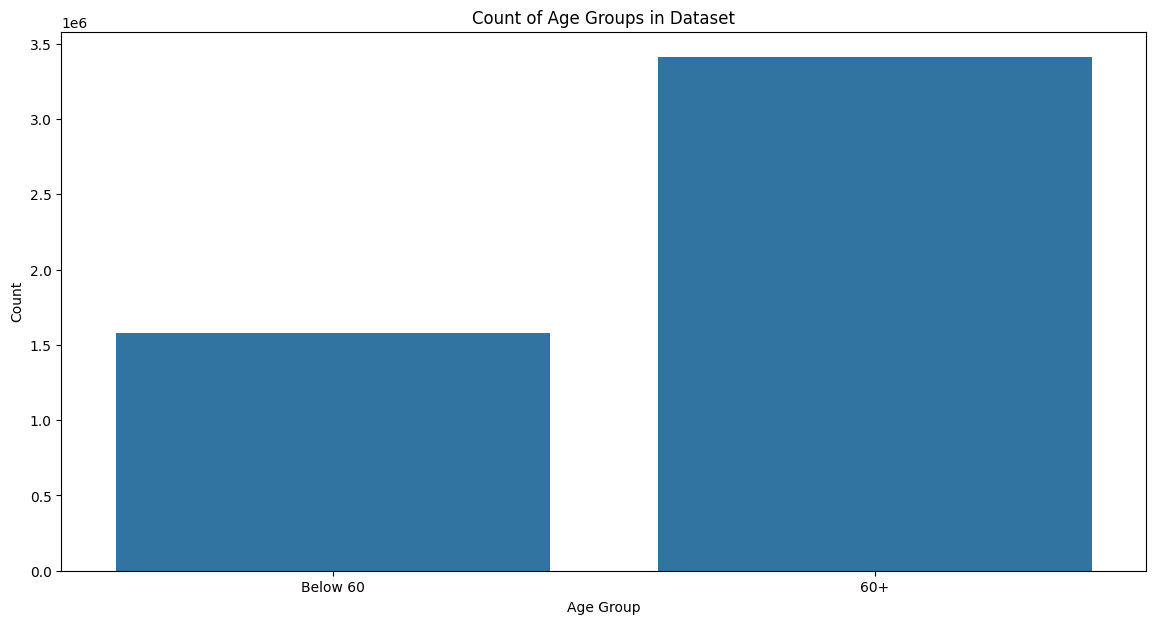

In [37]:
def plot_age_groups(train_data, test_data):
    plt.figure(figsize=(14, 7))

    # Define age groups based on age 60 directly for visualization
    train_age_group = train_data['Age'].apply(lambda x: '60+' if x >= 60 else 'Below 60')
    test_age_group = test_data['Age'].apply(lambda x: '60+' if x >= 60 else 'Below 60')

    # Combine the age groups for plotting
    combined_age_groups = pd.concat([train_age_group, test_age_group])

    # Count plot for age groups
    sns.countplot(x=combined_age_groups, order=['Below 60', '60+'])
    plt.title('Count of Age Groups in Dataset')
    plt.xlabel('Age Group')
    plt.ylabel('Count')

    # Show the plot
    plt.savefig("../results/age_group_distribution.png")
    plt.show()

# Call the function to plot data without modifying the original DataFrame
plot_age_groups(train_data, test_data)



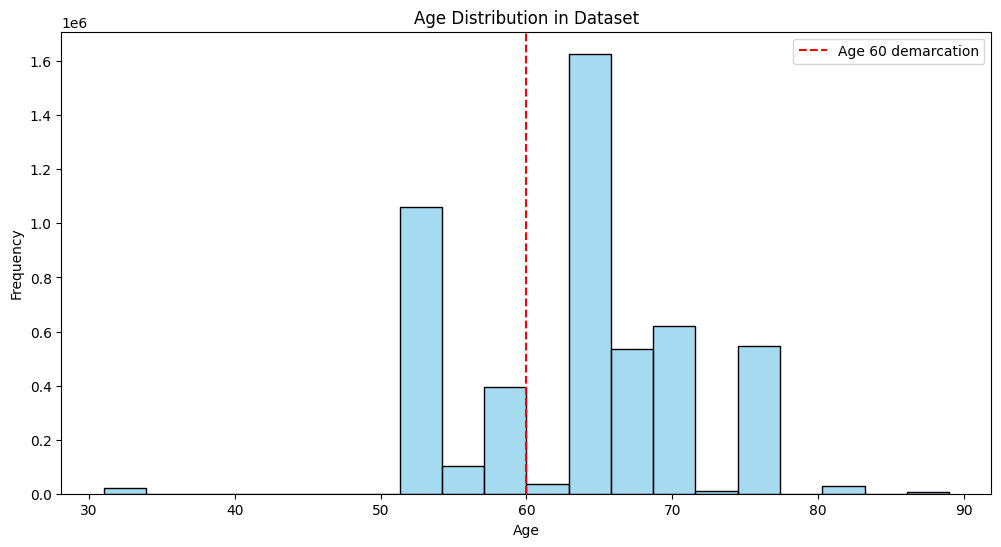

In [38]:
def plot_age_distribution(train_data, test_data):
    plt.figure(figsize=(12, 6))

    # Combine both datasets for a comprehensive plot
    combined_ages = pd.concat([train_data['Age'], test_data['Age']], axis=0)

    # Creating a histogram of age distribution
    sns.histplot(combined_ages, bins=20, kde=False, color='skyblue')
    plt.axvline(x=60, color='red', linestyle='--', label='Age 60 demarcation')
    plt.title('Age Distribution in Dataset')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend()

    # Show the plot
    plt.savefig("../results/age_distribution_60_threshold.png")
    plt.show()

# Call the function to plot data without modifying the original DataFrame
plot_age_distribution(train_data, test_data)



In [39]:
# One-Hot Encoding for 'Hand', 'Direction', and 'Sided' Columns
categorical_columns = ['Hand', 'Direction', 'Sided']

train_data = pd.get_dummies(train_data, columns=categorical_columns)
test_data = pd.get_dummies(test_data, columns=categorical_columns)

# Ensuring both train and test have the same columns after one-hot encoding
train_data, test_data = train_data.align(test_data, join='inner', axis=1)

print("\nShape of training data after one-hot encoding:")
print(train_data.shape)
print("\nShape of test data after one-hot encoding:")
print(test_data.shape)



Shape of training data after one-hot encoding:
(2780000, 34)

Shape of test data after one-hot encoding:
(2207865, 34)


In [40]:
print(train_data.head())

      UserKey    Date     Timestamp  Holdtime  Latencytime  Flighttime  \
0  NMMGWRY6SO  170301  08:45:42.125  0.872905     0.853579    0.719456   
1  NMMGWRY6SO  170301  08:45:42.422  0.945531     0.568445    0.238193   
2  NMMGWRY6SO  170301  08:48:29.031  0.945531     0.600081    0.318275   
4  NMMGWRY6SO  170301  08:48:29.484  0.872905     0.504969    0.077772   
5  NMMGWRY6SO  170301  08:49:14.234  0.945531     0.409856    0.077772   

   BirthYear Gender Parkinsons Tremors  ... Direction_LS Direction_RL  \
0     1948.0   Male       True   False  ...        False        False   
1     1948.0   Male       True   False  ...        False        False   
2     1948.0   Male       True   False  ...        False        False   
4     1948.0   Male       True   False  ...        False        False   
5     1948.0   Male       True   False  ...        False         True   

  Direction_RR Direction_RS Direction_SL Direction_SR Direction_SS  \
0        False        False        False      

In [41]:
# List of columns to convert to 0 and 1
columns_to_convert = ['Parkinsons', 'Tremors', 'DA', 'MAOB', 'Other']

# Function to convert strings to binary values
def convert_to_binary(value):
    value = str(value).strip().lower()  # Converting to string, strip whitespace, and convert to lowercase
    if value in ['yes', 'true', '1', 'positive']:
        return 1
    else:
        return 0

# Converting specified columns in train_data
for column in columns_to_convert:
    train_data[column] = train_data[column].apply(convert_to_binary)

# Converting specified columns in test_data
for column in columns_to_convert:
    test_data[column] = test_data[column].apply(convert_to_binary)

# Converting all boolean columns to 0 and 1 in train_data
boolean_columns = train_data.select_dtypes(include=['bool']).columns
train_data[boolean_columns] = train_data[boolean_columns].astype(int)

# Converting all boolean columns to 0 and 1 in test_data
boolean_columns = test_data.select_dtypes(include=['bool']).columns
test_data[boolean_columns] = test_data[boolean_columns].astype(int)

print(train_data.head())
print(test_data.head())


      UserKey    Date     Timestamp  Holdtime  Latencytime  Flighttime  \
0  NMMGWRY6SO  170301  08:45:42.125  0.872905     0.853579    0.719456   
1  NMMGWRY6SO  170301  08:45:42.422  0.945531     0.568445    0.238193   
2  NMMGWRY6SO  170301  08:48:29.031  0.945531     0.600081    0.318275   
4  NMMGWRY6SO  170301  08:48:29.484  0.872905     0.504969    0.077772   
5  NMMGWRY6SO  170301  08:49:14.234  0.945531     0.409856    0.077772   

   BirthYear Gender  Parkinsons  Tremors  ... Direction_LS Direction_RL  \
0     1948.0   Male           1        0  ...            0            0   
1     1948.0   Male           1        0  ...            0            0   
2     1948.0   Male           1        0  ...            0            0   
4     1948.0   Male           1        0  ...            0            0   
5     1948.0   Male           1        0  ...            0            1   

  Direction_RR Direction_RS  Direction_SL  Direction_SR  Direction_SS  \
0            0            0    

In [42]:
print(train_data.nunique())

UserKey               44
Date                 397
Timestamp        2527042
Holdtime             882
Latencytime         1924
Flighttime          1583
BirthYear             21
Gender                 2
Parkinsons             2
Tremors                2
DiagnosisYear          9
UPDRS                  1
Impact                 2
Levadopa               1
DA                     2
MAOB                   2
Other                  2
Age                   21
Age_Group              2
Hand_L                 2
Hand_R                 2
Hand_S                 2
Direction_LL           2
Direction_LR           2
Direction_LS           2
Direction_RL           2
Direction_RR           2
Direction_RS           2
Direction_SL           2
Direction_SR           2
Direction_SS           2
Sided_Left             2
Sided_None             2
Sided_Right            2
dtype: int64


In [43]:
# Function to convert gender to binary values
def convert_gender_to_binary(value):
    value = str(value).strip().lower()  # Convert to string, strip whitespace, and convert to lowercase
    if value == 'male':
        return 0
    else:
        return 1

# Converting 'Gender' column in train_data
train_data['Gender'] = train_data['Gender'].apply(convert_gender_to_binary)

# Converting 'Gender' column in test_data
test_data['Gender'] = test_data['Gender'].apply(convert_gender_to_binary)

print(train_data[['Gender']].head())
print(test_data[['Gender']].head())


   Gender
0       0
1       0
2       0
4       0
5       0
        Gender
188801       1
188802       1
188803       1
188804       1
188805       1


/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/3079843126.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=train_gender_counts.index, y=train_gender_counts.values, palette="Set2")


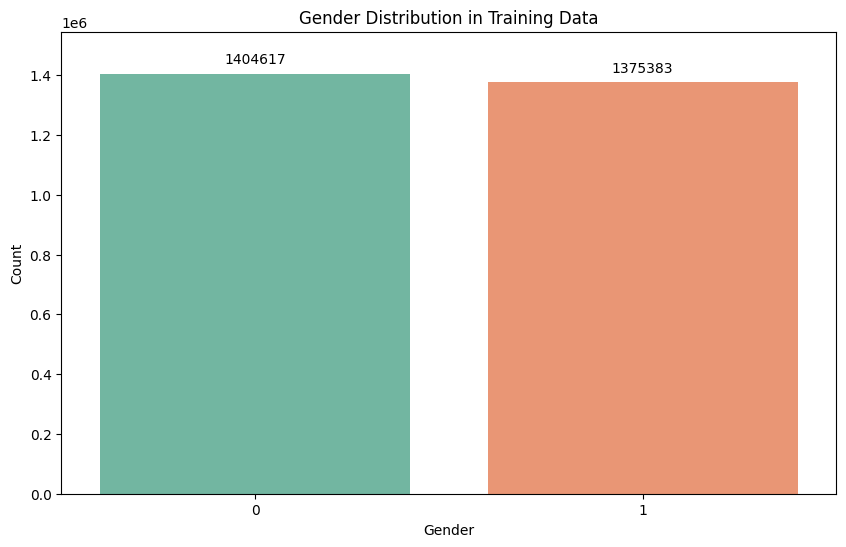

/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/3079843126.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=test_gender_counts.index, y=test_gender_counts.values, palette="Set2")


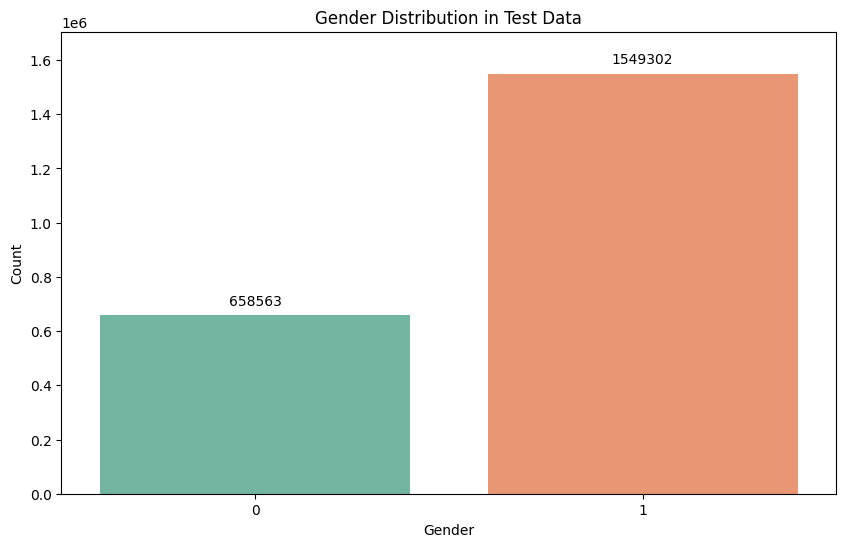

In [44]:
# Assuming your train_data and test_data have already been processed to have a 'Gender' column with binary values
# Calculate gender counts for training data
train_gender_counts = train_data['Gender'].value_counts()

# Calculate gender counts for test data
test_gender_counts = test_data['Gender'].value_counts()

# Now plotting
import matplotlib.pyplot as plt
import seaborn as sns

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Plotting the gender distribution for training data
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=train_gender_counts.index, y=train_gender_counts.values, palette="Set2")
add_labels(ax)
plt.title('Gender Distribution in Training Data')
plt.ylabel('Count')
plt.ylim(0, max(train_gender_counts.values) * 1.1)  # Adjust the y-axis limit for better spacing
plt.savefig("../results/gender_distribution_training.png")
plt.show()

# Plotting the gender distribution for test data
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=test_gender_counts.index, y=test_gender_counts.values, palette="Set2")
add_labels(ax)
plt.title('Gender Distribution in Test Data')
plt.ylabel('Count')
plt.ylim(0, max(test_gender_counts.values) * 1.1)  # Adjust the y-axis limit for better spacing
plt.savefig("../results/gender_distribution_test.png")
plt.show()



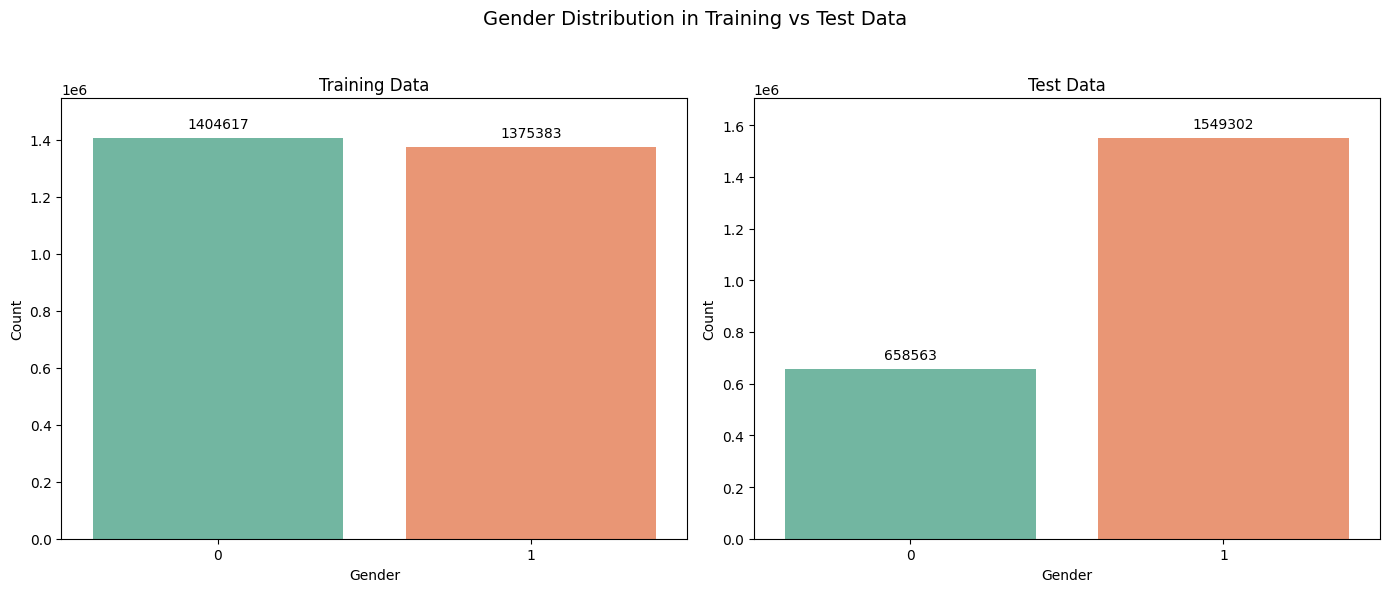

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10), textcoords='offset points')

# --- Training Data ---
sns.barplot(
    x=train_gender_counts.index,
    y=train_gender_counts.values,
    hue=train_gender_counts.index,   # fix warning
    palette="Set2",
    legend=False,
    ax=axes[0]
)
add_labels(axes[0])
axes[0].set_title('Training Data')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(train_gender_counts.values) * 1.1)

# --- Test Data ---
sns.barplot(
    x=test_gender_counts.index,
    y=test_gender_counts.values,
    hue=test_gender_counts.index,   # fix warning
    palette="Set2",
    legend=False,
    ax=axes[1]
)
add_labels(axes[1])
axes[1].set_title('Test Data')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(test_gender_counts.values) * 1.1)

# --- Main Title ---
fig.suptitle("Gender Distribution in Training vs Test Data", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/gender_distribution_training_vs_test.png")
plt.show()

In [45]:
print(test_data.nunique())

UserKey               20
Date                 371
Timestamp        2068980
Holdtime             712
Latencytime         1853
Flighttime          1651
BirthYear             15
Gender                 2
Parkinsons             2
Tremors                2
DiagnosisYear          7
UPDRS                  1
Impact                 2
Levadopa               1
DA                     2
MAOB                   2
Other                  2
Age                   15
Age_Group              2
Hand_L                 2
Hand_R                 2
Hand_S                 2
Direction_LL           2
Direction_LR           2
Direction_LS           2
Direction_RL           2
Direction_RR           2
Direction_RS           2
Direction_SL           2
Direction_SR           2
Direction_SS           2
Sided_Left             2
Sided_None             2
Sided_Right            2
dtype: int64


In [46]:
print(f'Training set shape: {train_data.shape}')
print(f'Test set shape: {test_data.shape}')

Training set shape: (2780000, 34)
Test set shape: (2207865, 34)


In [47]:
print(train_data.head())

      UserKey    Date     Timestamp  Holdtime  Latencytime  Flighttime  \
0  NMMGWRY6SO  170301  08:45:42.125  0.872905     0.853579    0.719456   
1  NMMGWRY6SO  170301  08:45:42.422  0.945531     0.568445    0.238193   
2  NMMGWRY6SO  170301  08:48:29.031  0.945531     0.600081    0.318275   
4  NMMGWRY6SO  170301  08:48:29.484  0.872905     0.504969    0.077772   
5  NMMGWRY6SO  170301  08:49:14.234  0.945531     0.409856    0.077772   

   BirthYear  Gender  Parkinsons  Tremors  ... Direction_LS Direction_RL  \
0     1948.0       0           1        0  ...            0            0   
1     1948.0       0           1        0  ...            0            0   
2     1948.0       0           1        0  ...            0            0   
4     1948.0       0           1        0  ...            0            0   
5     1948.0       0           1        0  ...            0            1   

  Direction_RR Direction_RS  Direction_SL  Direction_SR  Direction_SS  \
0            0           

In [48]:
# Checking for overlapping user identifiers and identical rows after preprocessing
train_user_keys = set(train_data['UserKey'])
test_user_keys = set(test_data['UserKey'])
overlap = train_user_keys.intersection(test_user_keys)
if len(overlap) > 0:
    print("Warning: Data leakage detected in UserKeys!")
else:
    print("No UserKey leakage detected.")

# Checking for identical rows between train and test sets
train_data_without_keys = train_data.drop(columns=['UserKey'], errors='ignore')
test_data_without_keys = test_data.drop(columns=['UserKey'], errors='ignore')
duplicated_rows = pd.merge(train_data_without_keys, test_data_without_keys, how='inner')
if not duplicated_rows.empty:
    print(f"Warning: Data leakage detected! {duplicated_rows.shape[0]} identical rows found between train and test sets.")
else:
    print("No identical rows found between train and test sets.")


No UserKey leakage detected.
No identical rows found between train and test sets.


In [49]:
# List of columns to drop
columns_to_drop = ['UserKey', 'Date', 'Timestamp', 'BirthYear', 'DiagnosisYear', 'UPDRS', 'Impact', 'Levadopa', 'Age']

# Dropping columns in train and test data
train_data = train_data.drop(columns=columns_to_drop)
test_data = test_data.drop(columns=columns_to_drop)

print("Remaining columns in train_data:")
print(train_data.columns)

print("Remaining columns in test_data:")
print(test_data.columns)


Remaining columns in train_data:
Index(['Holdtime', 'Latencytime', 'Flighttime', 'Gender', 'Parkinsons',
       'Tremors', 'DA', 'MAOB', 'Other', 'Age_Group', 'Hand_L', 'Hand_R',
       'Hand_S', 'Direction_LL', 'Direction_LR', 'Direction_LS',
       'Direction_RL', 'Direction_RR', 'Direction_RS', 'Direction_SL',
       'Direction_SR', 'Direction_SS', 'Sided_Left', 'Sided_None',
       'Sided_Right'],
      dtype='object')
Remaining columns in test_data:
Index(['Holdtime', 'Latencytime', 'Flighttime', 'Gender', 'Parkinsons',
       'Tremors', 'DA', 'MAOB', 'Other', 'Age_Group', 'Hand_L', 'Hand_R',
       'Hand_S', 'Direction_LL', 'Direction_LR', 'Direction_LS',
       'Direction_RL', 'Direction_RR', 'Direction_RS', 'Direction_SL',
       'Direction_SR', 'Direction_SS', 'Sided_Left', 'Sided_None',
       'Sided_Right'],
      dtype='object')


In [50]:
import pandas as pd

# Creating a DataFrame from the columns
columns_df = pd.DataFrame(train_data.columns, columns=['Remaining Columns'])

# Display the table
columns_df.style.set_properties(**{'text-align': 'left'})


,Remaining Columns
0,Holdtime
1,Latencytime
2,Flighttime
3,Gender
4,Parkinsons
5,Tremors
6,DA
7,MAOB
8,Other
9,Age_Group


# Correlation Matrix

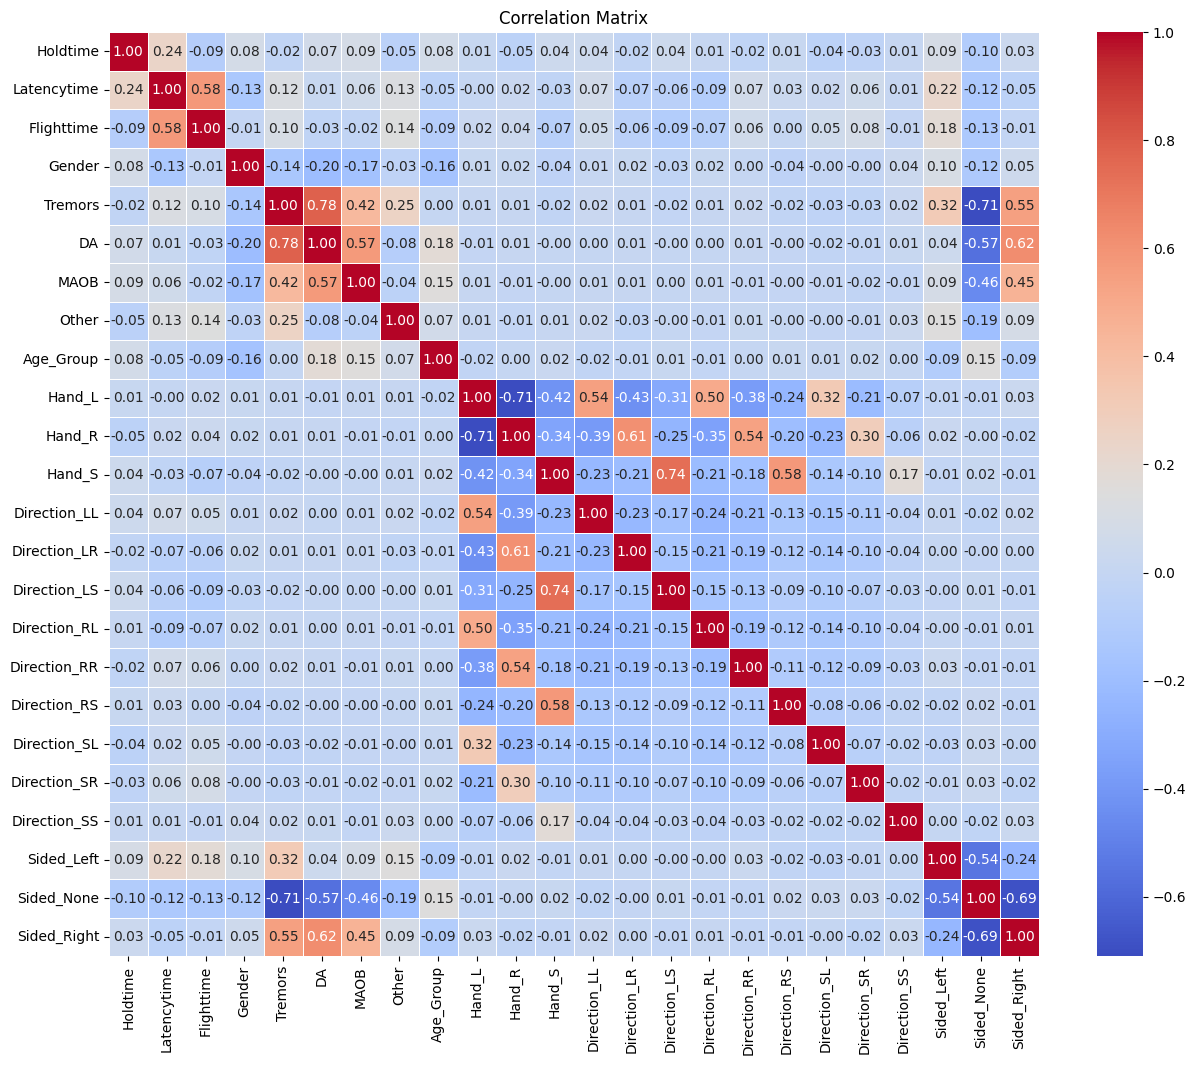


Features to remove: set()


In [52]:
# Computing the correlation matrix excluding the target variable
corr_matrix = train_data.drop(columns=['Parkinsons']).corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.savefig("../results/correlation_matrix.png")
plt.show()

# Finding pairs of highly correlated features (correlation > 0.8)
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Determining features to remove
features_to_remove = set(pair[1] for pair in high_corr_pairs)

print(f"\nFeatures to remove: {features_to_remove}")

In [53]:
# Removing highly correlated features from the training and test data
train_data_reduced = train_data.drop(columns=features_to_remove)
test_data_reduced = test_data.drop(columns=features_to_remove)

print("\nTraining data shape after removing highly correlated features:", train_data_reduced.shape)
print("Test data shape after removing highly correlated features:", test_data_reduced.shape)


Training data shape after removing highly correlated features: (2780000, 25)
Test data shape after removing highly correlated features: (2207865, 25)


In [54]:
print(pd.Series(train_data_reduced['Parkinsons'].value_counts()))
print(pd.Series(test_data_reduced['Parkinsons'].value_counts()))


Parkinsons
0    1855137
1     924863
Name: count, dtype: int64
Parkinsons
1    1787134
0     420731
Name: count, dtype: int64


/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/1960261024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_data_reduced['Parkinsons'], palette="viridis")


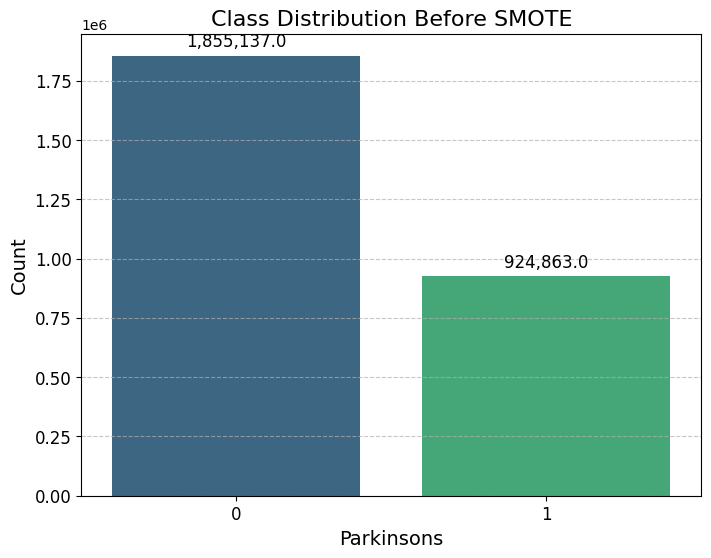

In [55]:
# Improved visualization of class distribution before SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=train_data_reduced['Parkinsons'], palette="viridis")
plt.title('Class Distribution Before SMOTE', fontsize=16)
plt.xlabel('Parkinsons', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adding value annotations on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                       textcoords='offset points')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../results/class_distribution_before_smote.png")
plt.show()


In [56]:
# Separating features and target variable from both train and test set
X_train = train_data_reduced.drop(columns=['Parkinsons']) 
y_train = train_data_reduced['Parkinsons']

X_test = test_data_reduced.drop(columns=['Parkinsons'])
y_test = test_data_reduced['Parkinsons']

# Feature Selection (Recursive Feature Elimination with Random Forest) 

In [58]:
# Defining the Random Forest classifier for RFE
rf_for_rfe = RandomForestClassifier(random_state=42)

# Performing RFE
rfe = RFE(estimator=rf_for_rfe, n_features_to_select=15)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)


# Applying SMOTE

In [60]:
# Applying SMOTE to the RFE-transformed data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rfe, y_train)

print("Shape of X_train before SMOTE:", X_train_rfe.shape)
print("Shape of X_train after SMOTE:", X_train_smote.shape)
print("Class distribution after SMOTE:\n", pd.Series(y_train_smote).value_counts())

Shape of X_train before SMOTE: (2780000, 15)
Shape of X_train after SMOTE: (3710274, 15)
Class distribution after SMOTE:
 Parkinsons
1    1855137
0    1855137
Name: count, dtype: int64


/var/folders/w2/6k1smck1755_h6hqds7jh85m0000gn/T/ipykernel_29777/99955631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette="viridis")


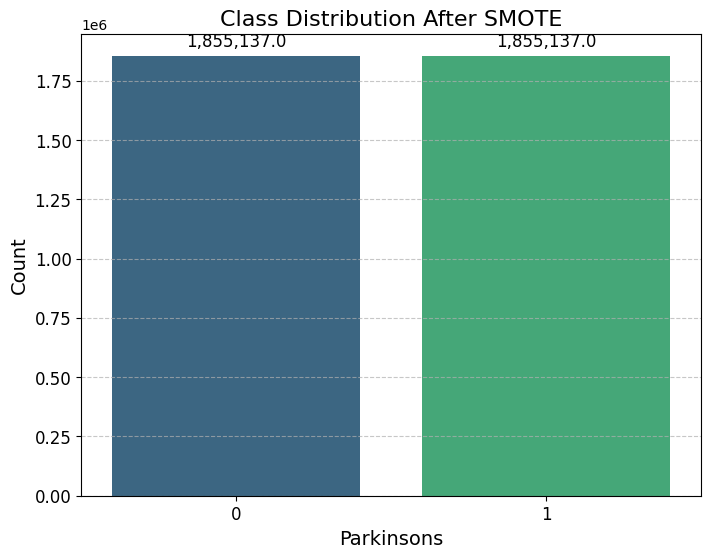

In [61]:
# Improved visualization of class distribution before SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote, palette="viridis")
plt.title('Class Distribution After SMOTE', fontsize=16)
plt.xlabel('Parkinsons', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adding value annotations on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                       textcoords='offset points')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../results/class_distribution_after_smote.png")
plt.show()



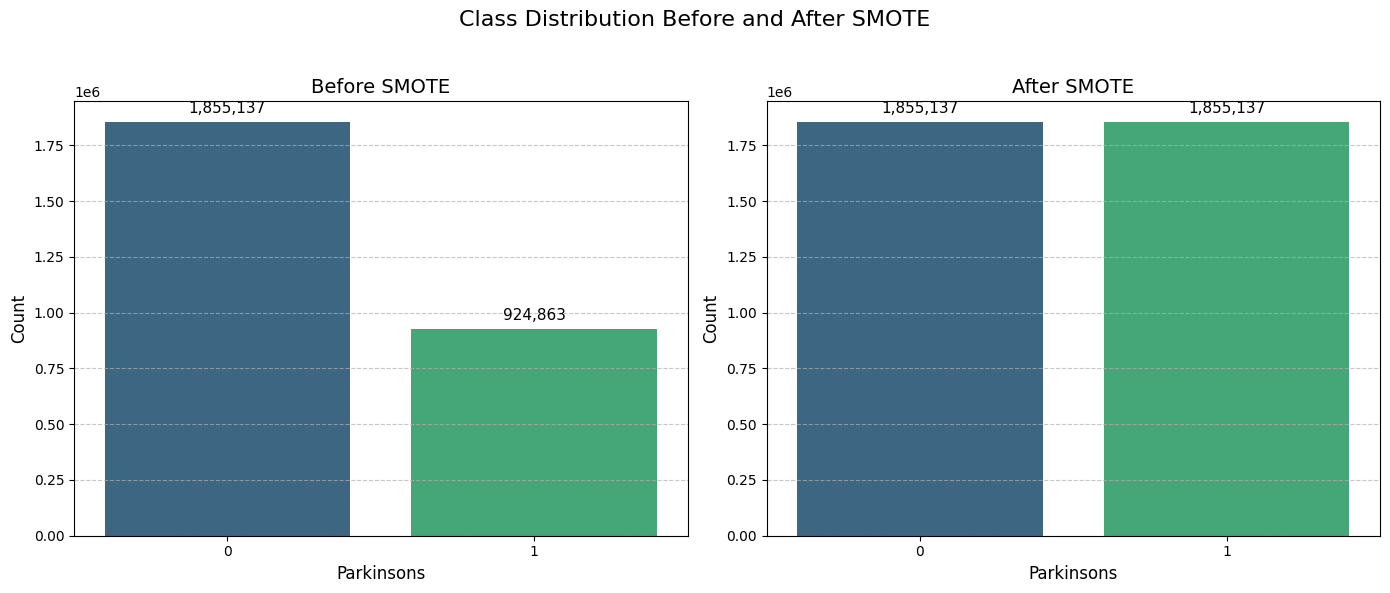

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Before SMOTE ---
sns.countplot(
    x=train_data_reduced['Parkinsons'],
    hue=train_data_reduced['Parkinsons'],
    palette="viridis",
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Before SMOTE', fontsize=14)
axes[0].set_xlabel('Parkinsons', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=11,
        color='black',
        xytext=(0, 10),
        textcoords='offset points'
    )

# --- After SMOTE ---
sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette="viridis",
    legend=False,
    ax=axes[1]
)
axes[1].set_title('After SMOTE', fontsize=14)
axes[1].set_xlabel('Parkinsons', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=11,
        color='black',
        xytext=(0, 10),
        textcoords='offset points'
    )

# --- Main title ---
fig.suptitle('Class Distribution Before and After SMOTE', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/class_distribution_before_and_after_smote.png")
plt.show()

## 🤖 Model Training
- Random Forest  
- Logistic Regression  

# Random Forest

In [118]:
# Fitting the model on SMOTE-applied RFE-reduced data

rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train_smote, y_train_smote)


RandomForestClassifier(random_state=42)

In [124]:
# Getting feature importance from the model after RFE
rfe_feature_importance = rf_classifier.feature_importances_

# Map RFE-selected features back to original features
selected_features = X_train.columns[rfe.support_]

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': rfe_feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print or display the feature importance
print(importance_df)

# Predict on the RFE-reduced test set
y_pred_smote = rf_classifier.predict(X_test_rfe)
print(f'Accuracy: {accuracy_score(y_test, y_pred_smote)}')
print(classification_report(y_test, y_pred_smote))
roc_auc = roc_auc_score(y_test, y_pred_smote)
print(f'ROC AUC Score: {roc_auc}')


         Feature  Importance
13    Sided_None    0.292123
14   Sided_Right    0.224615
4        Tremors    0.132081
6           MAOB    0.090151
5             DA    0.064676
7          Other    0.044234
12    Sided_Left    0.043612
3         Gender    0.033333
8      Age_Group    0.024952
0       Holdtime    0.021509
1    Latencytime    0.015169
2     Flighttime    0.012444
10        Hand_S    0.000412
9         Hand_R    0.000350
11  Direction_LL    0.000338
Accuracy: 0.9646658649872162
              precision    recall  f1-score   support

           0       0.85      0.99      0.91    420731
           1       1.00      0.96      0.98   1787134

    accuracy                           0.96   2207865
   macro avg       0.92      0.97      0.95   2207865
weighted avg       0.97      0.96      0.97   2207865

ROC AUC Score: 0.97261834754909


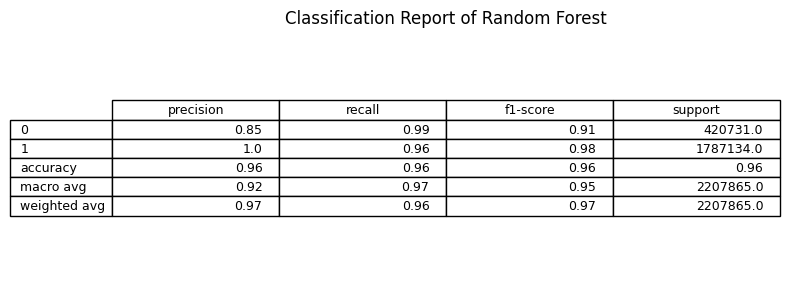

In [148]:
report = classification_report(y_test, y_pred_smote, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Keep main rows like sklearn output
display_df = report_df.loc[['0', '1', 'accuracy', 'macro avg', 'weighted avg']]

# Round values for clean display
display_df = display_df.round(2)

# Create table plot
fig, ax = plt.subplots(figsize=(8, 3))  # smaller figure
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.1)

plt.title("Classification Report of Random Forest", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("../results/random_forest_classification_report_after_smote.png",
            bbox_inches='tight', dpi=300)
plt.show()

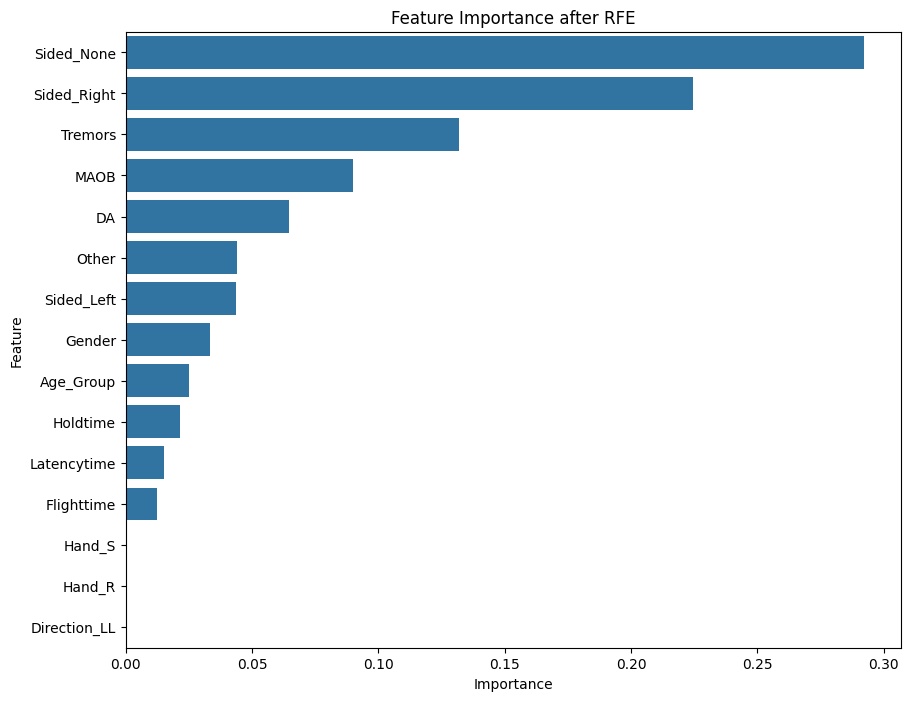

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance after RFE')
plt.savefig("../results/feature_importance_after_rfe.png")
plt.show()


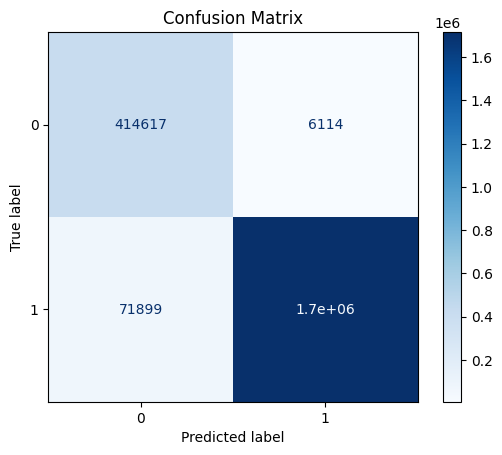

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


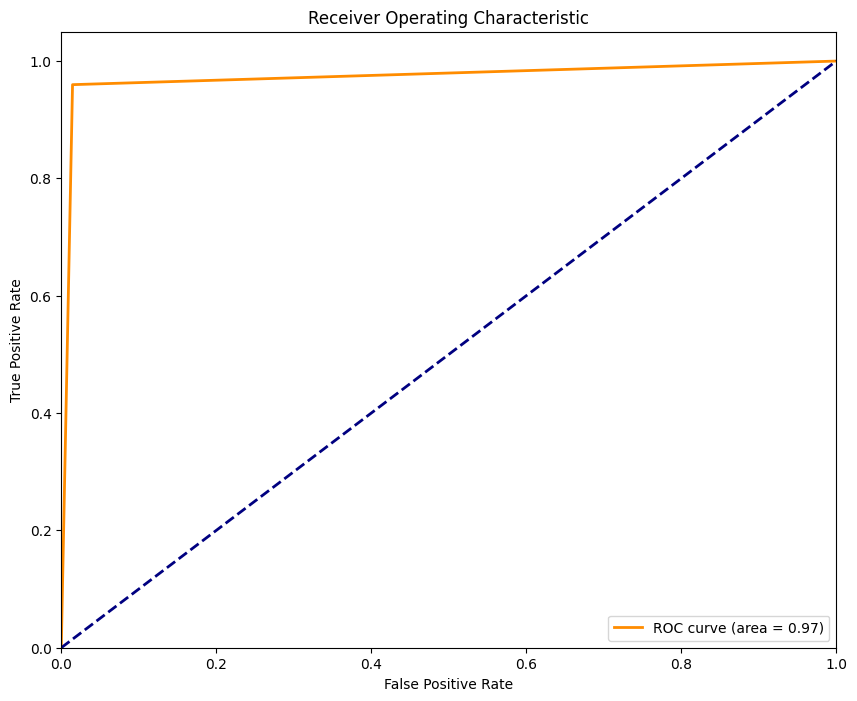

In [154]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


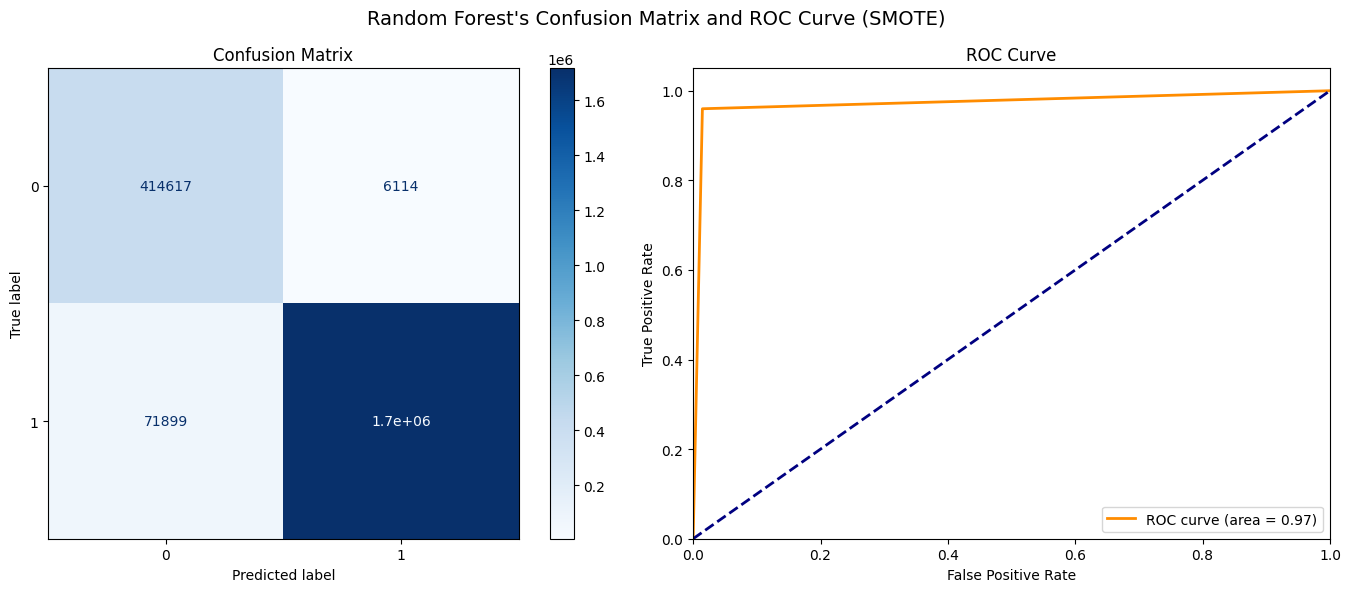

In [210]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Compute metrics
conf_mat = confusion_matrix(y_test, y_pred_smote)
fpr, tpr, _ = roc_curve(y_test, y_pred_smote)
roc_auc = auc(fpr, tpr)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Confusion Matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix')

# --- ROC Curve ---
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# --- Main Title ---
fig.suptitle("Random Forest's Confusion Matrix and ROC Curve (SMOTE)", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.savefig("../results/rf_confusion_matrix_and_roc_curve_with_smote.png")
plt.show()

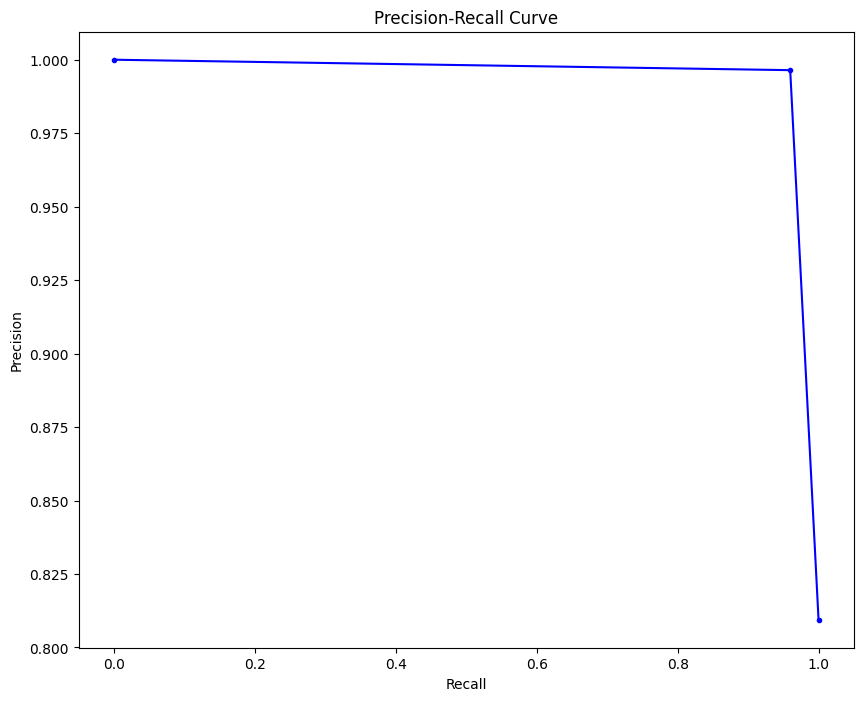

In [156]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Logistic Regression

In [158]:
# Defining the Logistic Regression classifier with class weights
log_reg_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Training the classifier on the original training data
log_reg_classifier.fit(X_train_smote, y_train_smote)

# Evaluating on test set
y_test_pred = log_reg_classifier.predict(X_test_rfe)
print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred)}')
print(classification_report(y_test, y_test_pred))
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print(f'Test ROC AUC Score: {test_roc_auc}')


Test Accuracy: 0.9496903116811942
              precision    recall  f1-score   support

           0       0.80      0.99      0.88    420731
           1       1.00      0.94      0.97   1787134

    accuracy                           0.95   2207865
   macro avg       0.90      0.97      0.93   2207865
weighted avg       0.96      0.95      0.95   2207865

Test ROC AUC Score: 0.9656548044059294


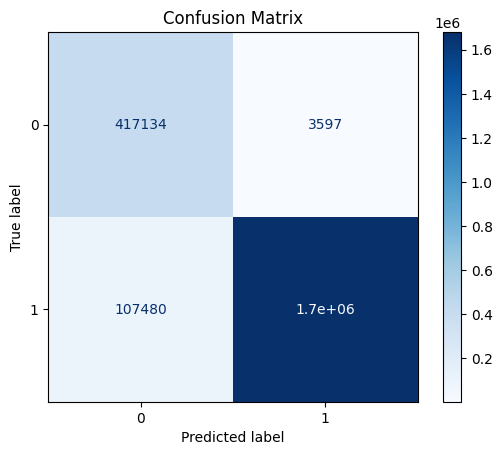

In [160]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


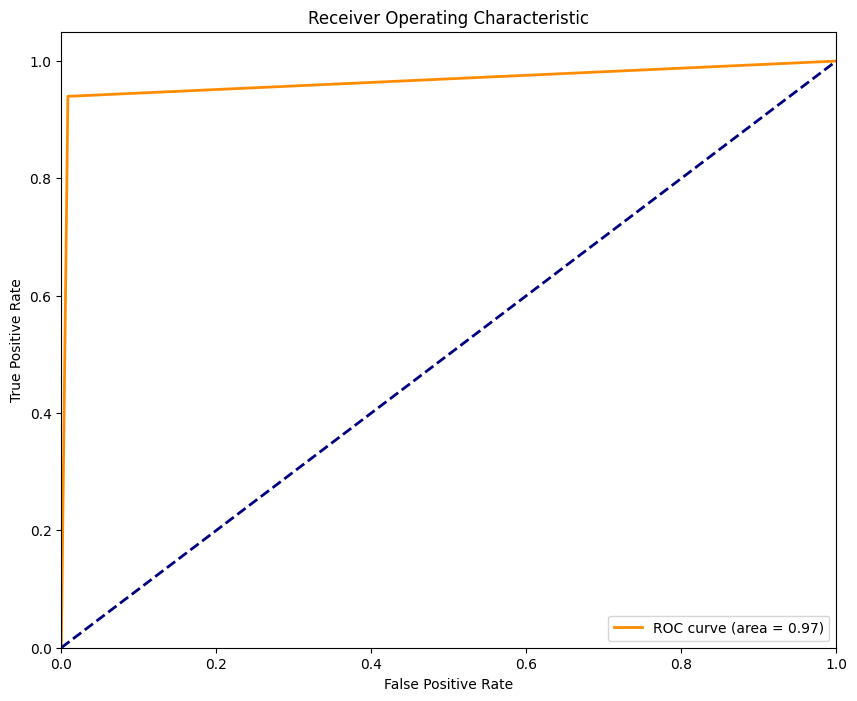

In [162]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


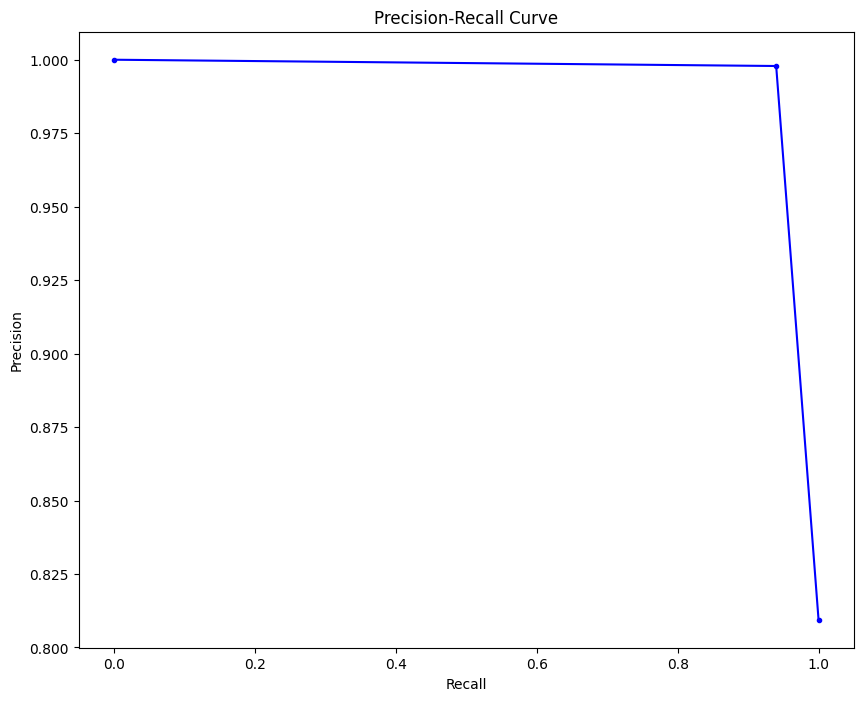

In [164]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Without SMOTE

# Random Forest

In [166]:
# Fitting the model on SMOTE-applied RFE-reduced data

rf_classifier_no_smote = RandomForestClassifier(random_state=42)


rf_classifier_no_smote.fit(X_train_rfe, y_train)


RandomForestClassifier(random_state=42)

In [168]:
# Getting feature importance from the model after RFE
rfe_feature_importance_no_smote = rf_classifier_no_smote.feature_importances_

# Map RFE-selected features back to original features
selected_features_no_smote = X_train.columns[rfe.support_]

# Create a DataFrame for better visualization of feature importances
importance_df_no_smote = pd.DataFrame({
    'Feature': selected_features_no_smote,
    'Importance': rfe_feature_importance_no_smote
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df_no_smote)

# Predict on the RFE-reduced test set using the model trained without SMOTE
y_pred_no_smote = rf_classifier_no_smote.predict(X_test_rfe)

# Evaluate the model's performance
print(f'Accuracy (No SMOTE): {accuracy_score(y_test, y_pred_no_smote)}')
print(classification_report(y_test, y_pred_no_smote))
roc_auc_no_smote = roc_auc_score(y_test, y_pred_no_smote)
print(f'ROC AUC Score (No SMOTE): {roc_auc_no_smote}')



         Feature  Importance
13    Sided_None    0.267585
14   Sided_Right    0.242362
4        Tremors    0.130005
6           MAOB    0.100443
5             DA    0.077573
7          Other    0.046057
12    Sided_Left    0.040434
3         Gender    0.032947
8      Age_Group    0.027472
0       Holdtime    0.016885
1    Latencytime    0.008886
2     Flighttime    0.008311
9         Hand_R    0.000379
10        Hand_S    0.000377
11  Direction_LL    0.000285
Accuracy (No SMOTE): 0.4915345820509859
              precision    recall  f1-score   support

           0       0.27      0.99      0.43    420731
           1       0.99      0.37      0.54   1787134

    accuracy                           0.49   2207865
   macro avg       0.63      0.68      0.48   2207865
weighted avg       0.86      0.49      0.52   2207865

ROC AUC Score (No SMOTE): 0.6814893320765862


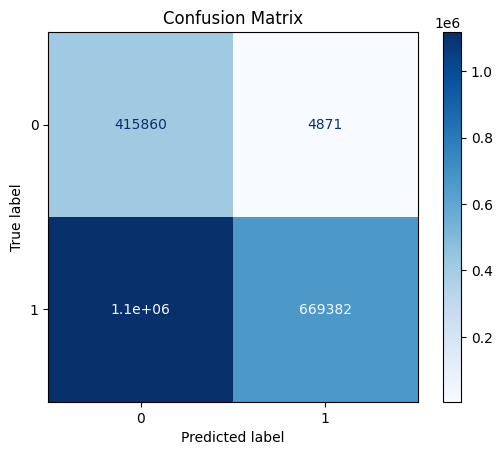

In [170]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_no_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


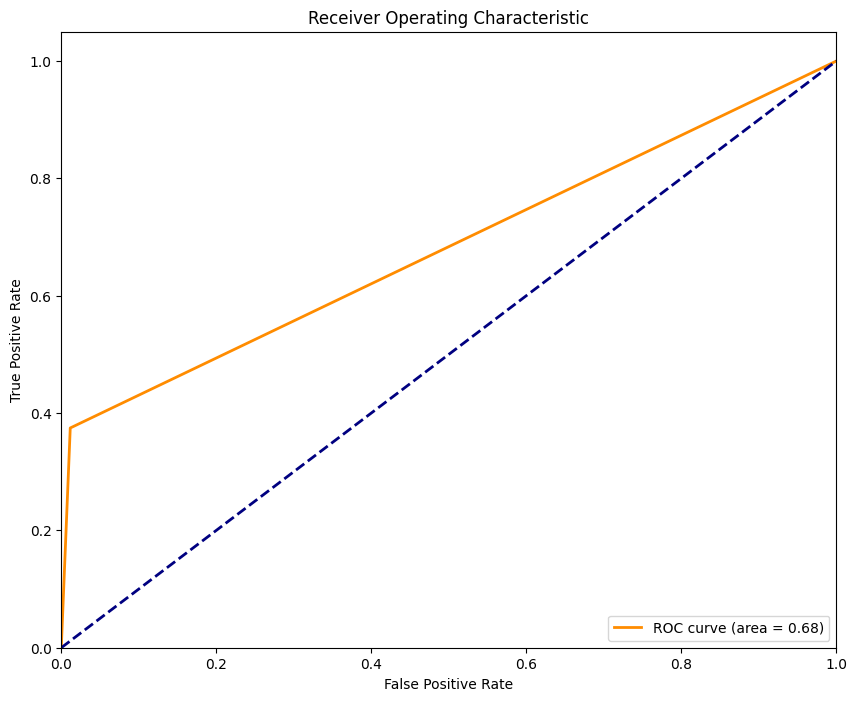

In [172]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_no_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


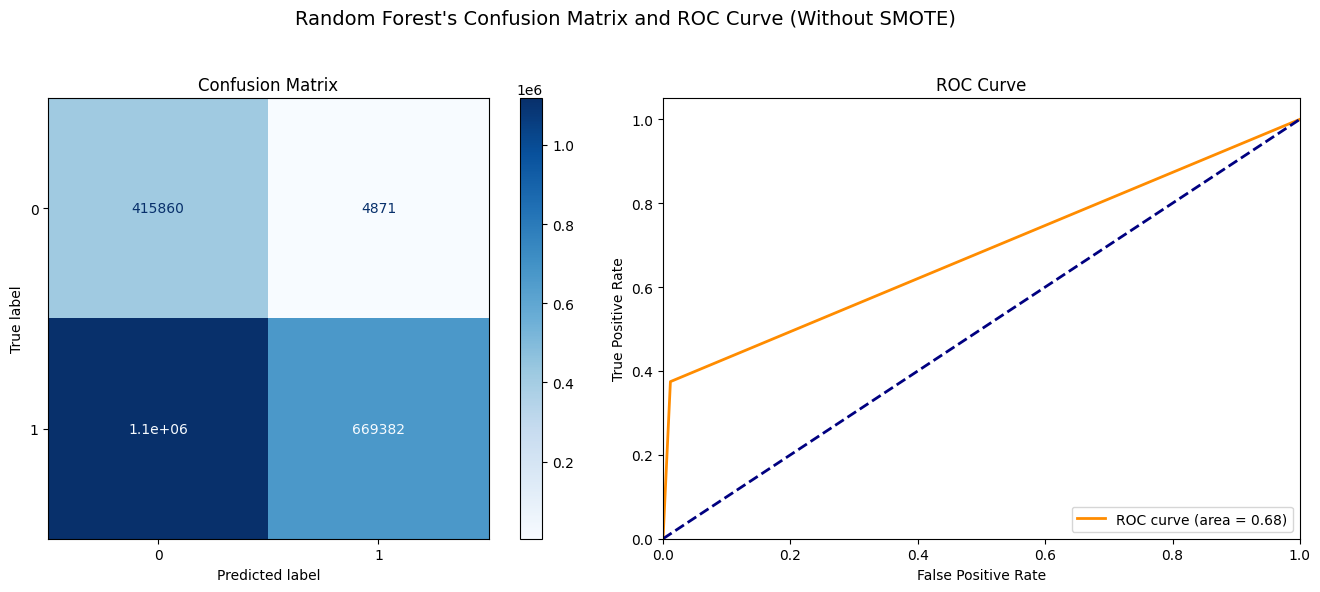

In [208]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Compute metrics
conf_mat = confusion_matrix(y_test, y_pred_no_smote)
fpr, tpr, _ = roc_curve(y_test, y_pred_no_smote)
roc_auc = auc(fpr, tpr)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Confusion Matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix')

# --- ROC Curve ---
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (area = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# --- Main Title ---
fig.suptitle("Random Forest's Confusion Matrix and ROC Curve (Without SMOTE)", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/rf_confusion_matrix_and_roc_curve_without_smote.png")
plt.show()

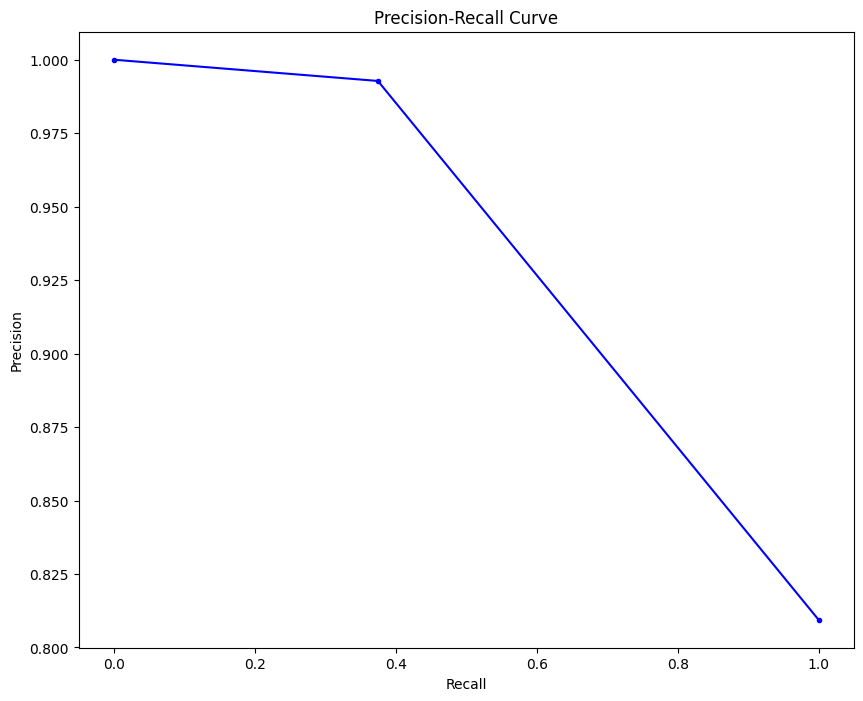

In [174]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_no_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Logistic Regression

In [176]:
# Defining the Logistic Regression classifier with class weights
log_reg_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Training the classifier on the original training data
log_reg_classifier.fit(X_train_rfe, y_train)

# Evaluating on test set
lr_y_pred_no_smote = log_reg_classifier.predict(X_test_rfe)
print(f'Accuracy (No SMOTE): {accuracy_score(y_test, lr_y_pred_no_smote)}')
print(classification_report(y_test, lr_y_pred_no_smote))
test_roc_auc = roc_auc_score(y_test, lr_y_pred_no_smote)
print(f'ROC AUC Score (No SMOTE): {test_roc_auc}')


Accuracy (No SMOTE): 0.9424000108702298
              precision    recall  f1-score   support

           0       0.77      0.99      0.87    420731
           1       1.00      0.93      0.96   1787134

    accuracy                           0.94   2207865
   macro avg       0.88      0.96      0.92   2207865
weighted avg       0.95      0.94      0.94   2207865

ROC AUC Score (No SMOTE): 0.9612023880021643


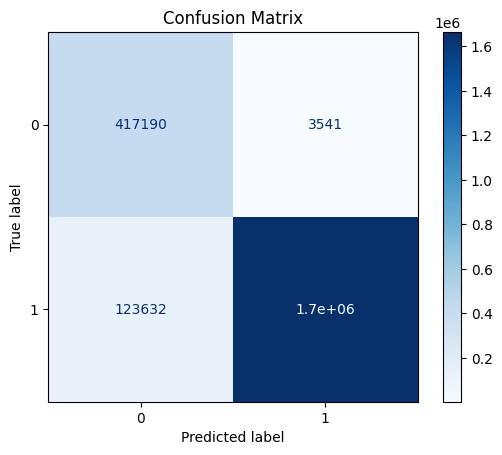

In [178]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, lr_y_pred_no_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


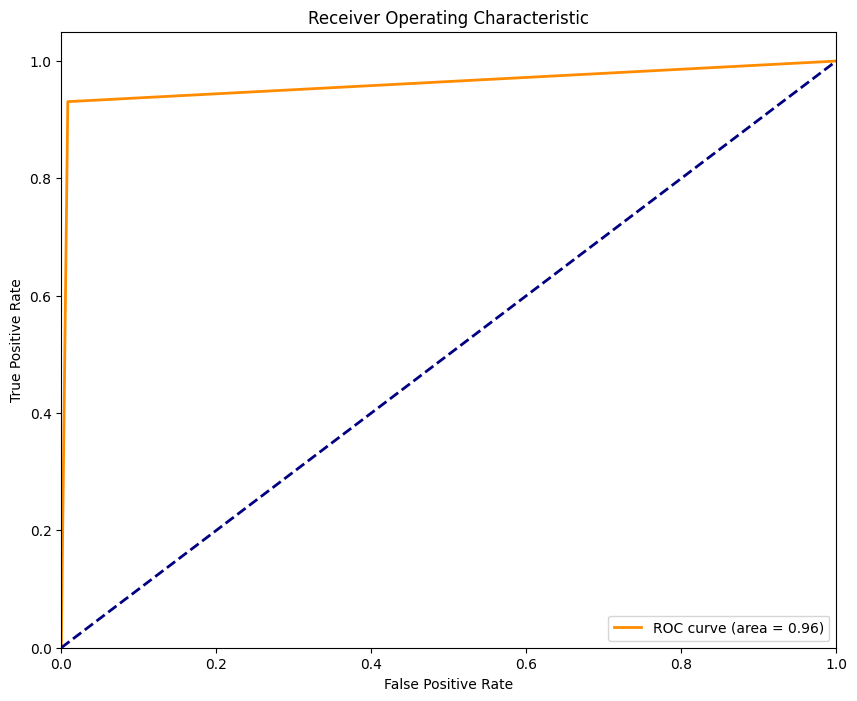

In [180]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_y_pred_no_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


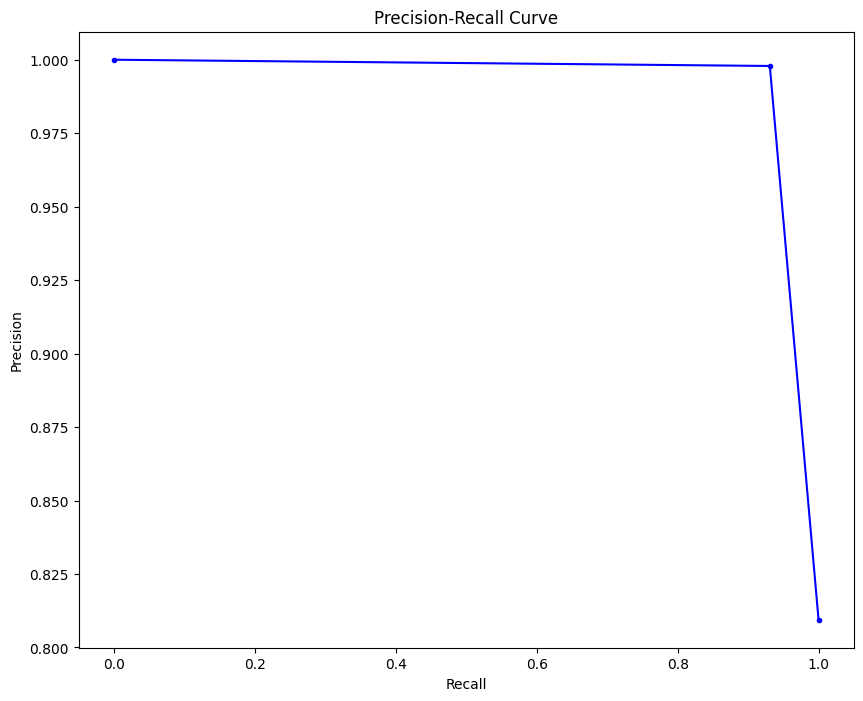

In [182]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, lr_y_pred_no_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


In [184]:
# import pandas as pd
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# # Store results
# results = []

# def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, smote_used):
#     # Train
#     model.fit(X_train, y_train)
    
#     # Predict
#     y_pred = model.predict(X_test)
    
#     # Metrics (PD = class 1)
#     acc = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred, pos_label=1)
#     recall = recall_score(y_test, y_pred, pos_label=1)
#     f1 = f1_score(y_test, y_pred, pos_label=1)
    
#     # Store results
#     results.append({
#         "Model": model_name,
#         "SMOTE": "✅" if smote_used else "❌",
#         "Accuracy": round(acc, 4),
#         "Precision": round(precision, 4),
#         "Recall (PD class)": round(recall, 4),
#         "F1-score": round(f1, 4)
#     })

# # =========================
# # Run all combinations
# # =========================

# # Random Forest
# evaluate_model(rf_classifier_no_smote, X_train_rfe, y_train, X_test_rfe, y_test, "RF", False)
# evaluate_model(rf_classifier, X_train_smote, y_train_smote, X_test_rfe, y_test, "RF", True)

# # Logistic Regression
# evaluate_model(log_reg_classifier, X_train_rfe, y_train, X_test_rfe, y_test, "Logistic", False)
# evaluate_model(log_reg_classifier, X_train_smote, y_train_smote, X_test_rfe, y_test, "Logistic", True)

# # =========================
# # Create final table
# # =========================

# results_df = pd.DataFrame(results)

# # Sort for clean display
# results_df = results_df.sort_values(by=["Model", "SMOTE"], ascending=[True, False])

# print(results_df)

      Model SMOTE  Accuracy  Precision  Recall (PD class)  F1-score
2  Logistic     ❌    0.9424     0.9979             0.9308    0.9632
3  Logistic     ✅    0.9497     0.9979             0.9399    0.9680
0        RF     ❌    0.4915     0.9928             0.3746    0.5439
1        RF     ✅    0.9647     0.9964             0.9598    0.9778


In [188]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to compute metrics
def get_metrics(y_true, y_pred, model_name, smote_status):
    return {
        "Model": model_name,
        "SMOTE": smote_status,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-score": f1_score(y_true, y_pred, average='weighted')
    }

# Collect results
results = []

# Random Forest (SMOTE)
results.append(get_metrics(y_test, y_pred_smote, "Random Forest", "With SMOTE"))

# Logistic Regression (SMOTE)
results.append(get_metrics(y_test, y_test_pred, "Logistic Regression", "With SMOTE"))

# Random Forest (No SMOTE)
results.append(get_metrics(y_test, y_pred_no_smote, "Random Forest", "Without SMOTE"))

# Logistic Regression (No SMOTE)
results.append(get_metrics(y_test, lr_y_pred_no_smote, "Logistic Regression", "Without SMOTE"))

# Create DataFrame
results_df = pd.DataFrame(results)

# Round for nicer display

results_df = results_df.round(3)

print(results_df)

                 Model          SMOTE  Accuracy  Precision    Recall  F1-score
0        Random Forest     With SMOTE  0.964666   0.968963  0.964666  0.965616
1  Logistic Regression     With SMOTE  0.949690   0.959229  0.949690  0.951702
2        Random Forest  Without SMOTE  0.491535   0.855265  0.491535  0.521357
3  Logistic Regression  Without SMOTE  0.942400   0.954719  0.942400  0.944996


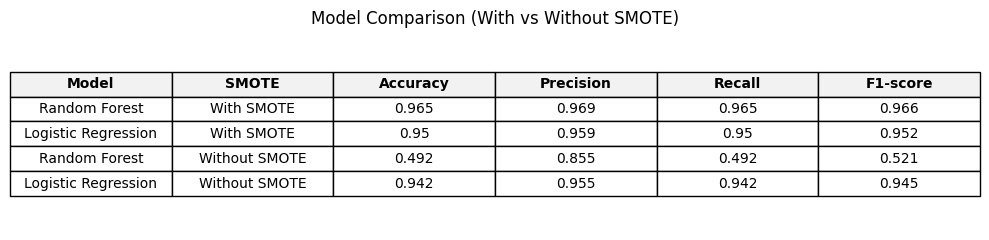

In [194]:
import matplotlib.pyplot as plt

# Round values first (important)
results_df_rounded = results_df.copy()
results_df_rounded.iloc[:, 2:] = results_df_rounded.iloc[:, 2:].astype(float).round(3)

# Create figure with better size
fig, ax = plt.subplots(figsize=(10, 2.5))  # adjust height if needed
ax.axis('off')

# Create table
table = ax.table(
    cellText=results_df_rounded.values,
    colLabels=results_df_rounded.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)  # increase row height

# Bold header + light grey background
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

# Title
plt.title("Model Comparison (With vs Without SMOTE)", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("../results/model_comparison_with_vs_without_smote.png")
plt.show()

# Selecting 10 features and 20 features to compare

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.feature_selection import RFE

def train_and_evaluate(features_count=None):
    # Check if specific features count is set, else use all features
    if features_count:
        # Using Random Forest for RFE
        rf_rfe = RandomForestClassifier(random_state=42)
        rfe_selector = RFE(estimator=rf_rfe, n_features_to_select=features_count)
        X_train_selected = rfe_selector.fit_transform(X_train, y_train)
        X_test_selected = rfe_selector.transform(X_test)
    else:
        # Use all features
        X_train_selected = X_train
        X_test_selected = X_test
    
    # Apply SMOTE
    smote_processor = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote_processor.fit_resample(X_train_selected, y_train)
    
    feature_info = "all features" if not features_count else f"top {features_count} features"
    print(f"Training with {feature_info}:")
    print("Shape of X_train after SMOTE:", X_train_balanced.shape)
    print("Class distribution after SMOTE:\n", pd.Series(y_train_balanced).value_counts())
    
    # Train Random Forest Classifier
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train_balanced, y_train_balanced)
    y_pred_rf = rf_model.predict(X_test_selected)
    rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]
    rf_roc_auc = roc_auc_score(y_test, rf_probs)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
    
    # Train Logistic Regression Classifier
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train_balanced, y_train_balanced)
    y_pred_lr = lr_model.predict(X_test_selected)
    lr_probs = lr_model.predict_proba(X_test_selected)[:, 1]
    lr_roc_auc = roc_auc_score(y_test, lr_probs)
    fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
    
    # Display results
    print("\nRandom Forest:")
    print(f'Accuracy: {accuracy_score(y_test, y_pred_rf)}')
    print(classification_report(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print(f'ROC AUC Score: {rf_roc_auc}')

    print("\nLogistic Regression:")
    print(f'Accuracy: {accuracy_score(y_test, y_pred_lr)}')
    print(classification_report(y_test, y_pred_lr))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
    print(f'ROC AUC Score: {lr_roc_auc}')
    
    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (area = {rf_roc_auc:.2f})')
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (area = {lr_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


Training with top 10 features:
Shape of X_train after SMOTE: (3710274, 10)
Class distribution after SMOTE:
 Parkinsons
1    1855137
0    1855137
Name: count, dtype: int64

Random Forest:
Accuracy: 0.49184619530632534
              precision    recall  f1-score   support

           0       0.27      0.99      0.43    420731
           1       0.99      0.37      0.54   1787134

    accuracy                           0.49   2207865
   macro avg       0.63      0.68      0.49   2207865
weighted avg       0.86      0.49      0.52   2207865

Confusion Matrix:
 [[ 416582    4149]
 [1117786  669348]]
ROC AUC Score: 0.9631951540633992

Logistic Regression:
Accuracy: 0.9432727997409261
              precision    recall  f1-score   support

           0       0.77      0.99      0.87    420731
           1       1.00      0.93      0.96   1787134

    accuracy                           0.94   2207865
   macro avg       0.89      0.96      0.92   2207865
weighted avg       0.96      0.94      0.

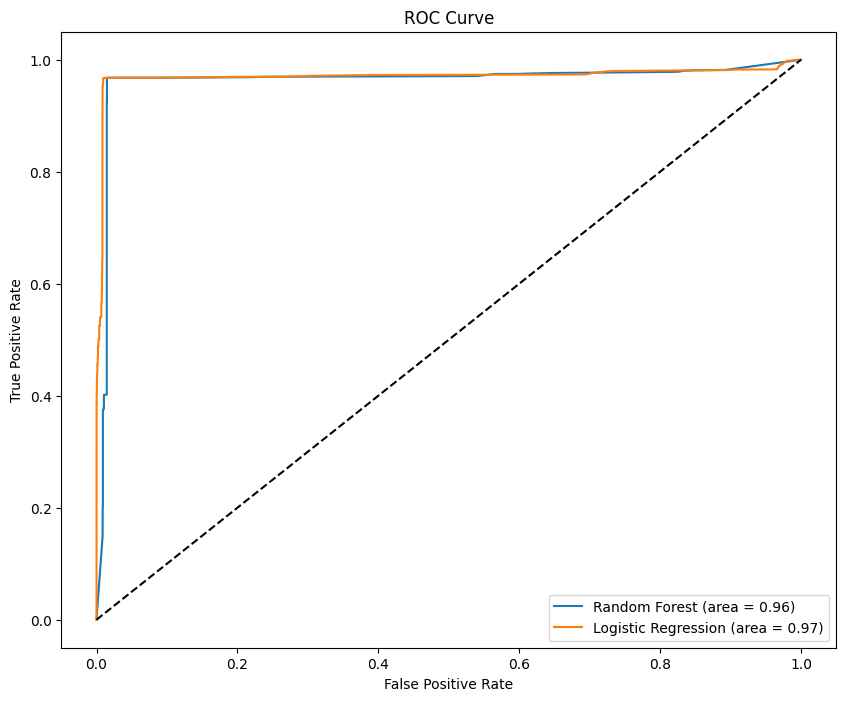

In [81]:
train_and_evaluate(10)

Training with top 20 features:
Shape of X_train after SMOTE: (3710274, 20)
Class distribution after SMOTE:
 Parkinsons
1    1855137
0    1855137
Name: count, dtype: int64

Random Forest:
Accuracy: 0.5398350895548415
              precision    recall  f1-score   support

           0       0.29      0.98      0.45    420731
           1       0.99      0.44      0.60   1787134

    accuracy                           0.54   2207865
   macro avg       0.64      0.71      0.53   2207865
weighted avg       0.86      0.54      0.58   2207865

Confusion Matrix:
 [[ 414363    6368]
 [1009614  777520]]
ROC AUC Score: 0.9663472389527701

Logistic Regression:
Accuracy: 0.95949118265836
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    420731
           1       1.00      0.95      0.97   1787134

    accuracy                           0.96   2207865
   macro avg       0.91      0.97      0.94   2207865
weighted avg       0.97      0.96      0.96 

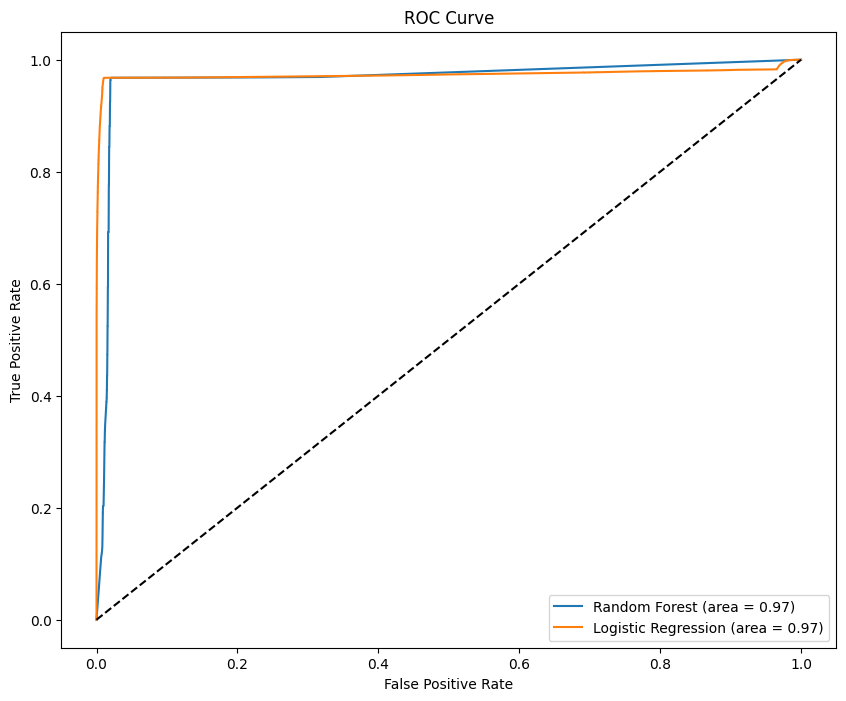

In [82]:
train_and_evaluate(20)

## ✅ Conclusion

The Random Forest model achieved the highest performance, demonstrating that keystroke dynamics can effectively detect early-stage Parkinson’s Disease.

Feature selection and SMOTE significantly improved model performance.